[Mohit Saharan](https://linkedin.com/in/msaharan), 20260506, P18, v2

Apache 2.0 License (see github.com/msaharan/dsaiengineering/LICENSE)

# Volatility-Regime Forecasting with TabPFN, TabICL, and Classical Tabular Models

This notebook evaluates a supervised tabular workflow for forecasting high-volatility market regimes. The objective is not to forecast the next price of an asset, make a trading recommendation, or claim that a model can produce investment returns. The objective is narrower: given features available at the close of date `t`, estimate whether SPY's realized volatility over the next 20 trading days will fall into a high-volatility regime.

The workflow is designed as a reusable, production-style research test rather than a leaderboard benchmark. It uses point-in-time feature construction, explicit chronological splits, a pre-holdout target-threshold policy, rolling-origin cross-validation, a tuned XGBoost benchmark on the configured accelerator, direct TabPFN and TabICL classifiers, offline TabPFN and TabICL row embeddings, calibration diagnostics, operating-point metrics, runtime accounting, block-bootstrap uncertainty, a risk-control diagnostic, drift checks, and leakage checks. Logistic Regression and Random Forest remain available as optional CPU benchmarks, but they are not part of the default GPU-first run.

All outputs needed for review are written to disk as CSV, TXT, PNG, and ZIP artifacts. Notebook display output is treated as a convenience view only.


## How to Run This Notebook on Kaggle

1. Import this notebook into Kaggle.
2. Enable GPU acceleration. The intended environment is Kaggle with two T4 GPUs.
3. Turn on Internet access. The notebook downloads packages, public market data, public macro data, and model checkpoints.
4. Add a Kaggle secret named `TABPFN_TOKEN` if local TabPFN weight access requires a token after accepting the Prior Labs license.
5. Optionally add `HF_TOKEN` for Hugging Face downloads. TabICL is usually downloadable without it, but using a token can avoid rate-limit issues.

The default classical workflow is XGBoost on the configured accelerator; the sklearn Logistic Regression and Random Forest benchmarks are disabled by default because they are CPU-only in this implementation. For a short smoke test, set `FAST_MODE = True` in the configuration cell before running the notebook. Fast mode reduces row counts, search iterations, TFM ensemble size, and bootstrap iterations so the full notebook path can be checked before a longer research run; fast-mode outputs should not be used as publication results.

This notebook writes reviewable artifacts to `tabpfn_tabicl_volatility_regime_20260506_outputs/` and creates a ZIP archive at the end of the run. The CSV, TXT, and PNG artifacts should be used for post-run analysis because notebook editor output can be truncated.


In [1]:
%%time
# Kaggle / Colab setup.
# Run this cell once. If imports still fail, restart the notebook session and continue below.

import subprocess
import sys

PYPI_PACKAGES = [
    "xgboost>=2.0.0",
    "rich",
    "yfinance>=0.2.40",
    "tabpfn",
    "tabicl",
    "cupy-cuda12x",
    "tqdm",
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PYPI_PACKAGES], check=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 16.9 MB/s eta 0:00:00
CPU times: user 2.41 ms, sys: 2.67 ms, total: 5.07 ms
Wall time: 8.2 s


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'xgboost>=2.0.0', 'rich', 'yfinance>=0.2.40', 'tabpfn', 'tabicl', 'cupy-cuda12x', 'tqdm'], returncode=0)

## 0. Imports, Secrets, and Configuration


In [2]:
import importlib.metadata as importlib_metadata
import math
import os
from pathlib import Path
import platform
import subprocess
import time
import warnings
from traceback import format_exception_only

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import yfinance as yf

from IPython.display import display
from rich.console import Console
from scipy.stats import loguniform, randint, uniform

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The `cv='prefit'` option is deprecated", category=FutureWarning)

console = Console()
SEED = 42
np.random.seed(SEED)

DATA_START_DATE = "2006-01-01"
DATA_END_DATE = "2026-05-02"  # yfinance end date is exclusive.
TARGET_ASSET = "SPY"
TARGET_HORIZON_DAYS = 20
HIGH_VOL_QUANTILE = 0.80
FEATURE_MAX_MISSING_RATE = 0.40
FEATURE_MIN_PRECALIBRATION_OBSERVATIONS = 30

CONTEXT_END_DATE = "2011-12-30"
TUNING_END_DATE = "2017-12-29"
CALIBRATION_END_DATE = "2019-12-31"
HOLDOUT_START_DATE = "2020-01-01"

FAST_MODE = True
FAST_MODE_CONTEXT_MAX_ROWS = 700
FAST_MODE_TUNE_MAX_ROWS = 900
FAST_MODE_CALIBRATION_MAX_ROWS = 350
FAST_MODE_HOLDOUT_MAX_ROWS = 500
FAST_MODE_N_TFM_ESTIMATORS = 2
FAST_MODE_XGBOOST_TUNING_ITERATIONS = 8
FAST_MODE_RANDOM_FOREST_TUNING_ITERATIONS = 6
FAST_MODE_LOGISTIC_TUNING_ITERATIONS = 6
FAST_MODE_CLASSICAL_TUNING_CV_SPLITS = 2
FAST_MODE_MIN_CV_TRAIN_POSITIVES = 5
FAST_MODE_MIN_CV_VALIDATION_POSITIVES = 2
FAST_MODE_BOOTSTRAP_ITERATIONS = 40

N_TFM_ESTIMATORS = 8
TFM_EMBEDDING_CHUNK_SIZE = 1024
CLASSICAL_TUNING_CV_SPLITS = 5
CLASSICAL_TUNING_EXECUTION = "sequential_progress"
XGBOOST_TUNING_ITERATIONS = 128
RANDOM_FOREST_TUNING_ITERATIONS = 80
LOGISTIC_TUNING_ITERATIONS = 48
MIN_CV_TRAIN_POSITIVES = 25
MIN_CV_VALIDATION_POSITIVES = 8
BOOTSTRAP_ITERATIONS = 300
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

if FAST_MODE:
    N_TFM_ESTIMATORS = min(N_TFM_ESTIMATORS, FAST_MODE_N_TFM_ESTIMATORS)
    CLASSICAL_TUNING_CV_SPLITS = min(CLASSICAL_TUNING_CV_SPLITS, FAST_MODE_CLASSICAL_TUNING_CV_SPLITS)
    XGBOOST_TUNING_ITERATIONS = min(XGBOOST_TUNING_ITERATIONS, FAST_MODE_XGBOOST_TUNING_ITERATIONS)
    RANDOM_FOREST_TUNING_ITERATIONS = min(RANDOM_FOREST_TUNING_ITERATIONS, FAST_MODE_RANDOM_FOREST_TUNING_ITERATIONS)
    LOGISTIC_TUNING_ITERATIONS = min(LOGISTIC_TUNING_ITERATIONS, FAST_MODE_LOGISTIC_TUNING_ITERATIONS)
    MIN_CV_TRAIN_POSITIVES = min(MIN_CV_TRAIN_POSITIVES, FAST_MODE_MIN_CV_TRAIN_POSITIVES)
    MIN_CV_VALIDATION_POSITIVES = min(MIN_CV_VALIDATION_POSITIVES, FAST_MODE_MIN_CV_VALIDATION_POSITIVES)
    BOOTSTRAP_ITERATIONS = min(BOOTSTRAP_ITERATIONS, FAST_MODE_BOOTSTRAP_ITERATIONS)

RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK = False
RUN_RANDOM_FOREST_CPU_BENCHMARK = False
RUN_XGBOOST = True
RUN_DIRECT_TABPFN = True
RUN_DIRECT_TABICL = True
RUN_TABPFN_EMBEDDINGS = True
RUN_TABICL_EMBEDDINGS = True
EVALUATE_CALIBRATION_VARIANTS = True

XGBOOST_TREE_METHOD = "hist"
XGBOOST_DEVICE = "cuda"
TABICL_CHECKPOINT_VERSION = "tabicl-classifier-v2-20260212.ckpt"
TABPFN_MODEL_NOTE = "default TabPFNClassifier checkpoint for the installed tabpfn package"

RISK_POLICY_TARGET_ACTION_RATE = 0.20
RISK_POLICY_HIGH_RISK_WEIGHT = 0.50
RISK_POLICY_GRID_ACTION_RATES = [0.10, 0.20, 0.30]
RISK_POLICY_GRID_HIGH_RISK_WEIGHTS = [0.00, 0.25, 0.50, 0.75]
RISK_POLICY_PLOT_ACTION_RATE = 0.20
RISK_POLICY_PLOT_HIGH_RISK_WEIGHT = 0.50
TRANSACTION_COST_BPS = 1.0
TRADING_DAYS_PER_YEAR = 252

ARTIFACT_DIR = Path("tabpfn_tabicl_volatility_regime_20260506_outputs")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
artifact_manifest_rows = []

PUBLICATION_MODEL_ORDER = [
    "Rule[SPY realized volatility 20d]",
    "Rule[VIX close]",
    "XGBoost[Raw all-history incumbent]",
    "XGBoost[Raw]",
    "XGBoost[Raw + TabPFN embeddings]",
    "XGBoost[Raw + TabICL embeddings]",
    "TabPFN[Direct all-history]",
    "TabICL[Direct all-history]",
]

CALIBRATION_MODEL_ORDER = [
    "XGBoost[Raw all-history incumbent] Calibration Base",
    "XGBoost[Raw all-history incumbent] Calibrated",
    "XGBoost[Raw] Calibration Base",
    "XGBoost[Raw] Calibrated",
    "XGBoost[Raw + TabPFN embeddings] Calibration Base",
    "XGBoost[Raw + TabPFN embeddings] Calibrated",
    "XGBoost[Raw + TabICL embeddings] Calibration Base",
    "XGBoost[Raw + TabICL embeddings] Calibrated",
]


def register_artifact(path, kind, description=""):
    path = Path(path)
    artifact_manifest_rows.append(
        {
            "path": str(path),
            "filename": path.name,
            "kind": kind,
            "description": description,
            "exists": path.exists(),
            "size_bytes": path.stat().st_size if path.exists() else np.nan,
        }
    )
    return path


def save_artifact_table(table, filename, index=False, description=""):
    output_path = ARTIFACT_DIR / filename
    table.to_csv(output_path, index=index)
    register_artifact(output_path, "table", description)
    print(f"Saved {output_path}")
    return output_path


def save_text_artifact(filename, text, description=""):
    output_path = ARTIFACT_DIR / filename
    output_path.write_text(str(text), encoding="utf-8")
    register_artifact(output_path, "text", description)
    print(f"Saved {output_path}")
    return output_path


def installed_version(*package_names):
    for package_name in package_names:
        try:
            return importlib_metadata.version(package_name)
        except importlib_metadata.PackageNotFoundError:
            continue
    return "not installed"


def safe_string(value):
    if value is None:
        return ""
    if isinstance(value, (list, tuple)):
        return ", ".join(str(item) for item in value)
    return str(value)


def short_error(exc):
    return "".join(format_exception_only(type(exc), exc)).strip().replace("\n", " ")[:500]


def git_commit_or_unavailable(path):
    path = Path(path)
    if not path.exists():
        return "not available"
    try:
        result = subprocess.run(
            ["git", "-C", str(path), "rev-parse", "HEAD"],
            capture_output=True,
            text=True,
            check=True,
            timeout=5,
        )
        return result.stdout.strip()
    except Exception:
        return "not a git checkout or unavailable"


def source_provenance_frame():
    cwd = Path.cwd().resolve()
    candidates = {
        "notebook_working_directory": cwd,
        "parent_directory": cwd.parent,
        "tabpfn_sibling_repo": cwd.parent / "tabpfn",
        "tabicl_sibling_repo": cwd.parent / "tabicl",
    }
    return pd.DataFrame(
        [
            {"Source": name, "Path": str(path), "Git Commit": git_commit_or_unavailable(path)}
            for name, path in candidates.items()
        ]
    )


def reset_cuda_peak_memory_stats():
    if not torch.cuda.is_available():
        return
    for device_index in range(torch.cuda.device_count()):
        torch.cuda.reset_peak_memory_stats(device_index)


def cuda_memory_snapshot(stage):
    if not torch.cuda.is_available():
        return pd.DataFrame()
    rows = []
    for device_index in range(torch.cuda.device_count()):
        free_bytes, total_bytes = torch.cuda.mem_get_info(device_index)
        rows.append(
            {
                "stage": stage,
                "device_index": device_index,
                "device_name": torch.cuda.get_device_name(device_index),
                "allocated_mb": torch.cuda.memory_allocated(device_index) / 1024**2,
                "reserved_mb": torch.cuda.memory_reserved(device_index) / 1024**2,
                "max_allocated_mb": torch.cuda.max_memory_allocated(device_index) / 1024**2,
                "free_mb": free_bytes / 1024**2,
                "total_mb": total_bytes / 1024**2,
            }
        )
    return pd.DataFrame(rows)


cuda_memory_snapshots = []


def record_cuda_memory(stage):
    snapshot = cuda_memory_snapshot(stage)
    if len(snapshot) > 0:
        cuda_memory_snapshots.append(snapshot)
    return snapshot


CUDA_DEVICE_COUNT = torch.cuda.device_count()
if CUDA_DEVICE_COUNT < 1:
    print("CUDA was not detected. The notebook can still build the dataset, but TFM and GPU-XGBoost sections are intended for a GPU runtime.")

TABICL_DEVICE = "cuda:0" if CUDA_DEVICE_COUNT else "cpu"
TABPFN_DEVICE = [f"cuda:{idx}" for idx in range(CUDA_DEVICE_COUNT)] if CUDA_DEVICE_COUNT else "cpu"

if CUDA_DEVICE_COUNT == 0:
    XGBOOST_DEVICE = "cpu"
    RUN_DIRECT_TABPFN = False
    RUN_DIRECT_TABICL = False
    RUN_TABPFN_EMBEDDINGS = False
    RUN_TABICL_EMBEDDINGS = False


def load_secret(name):
    value = os.environ.get(name)
    if value:
        return value
    try:
        from kaggle_secrets import UserSecretsClient
        value = UserSecretsClient().get_secret(name)
        if value:
            os.environ[name] = value
            return value
    except Exception:
        pass
    try:
        from google.colab import userdata
        value = userdata.get(name)
        if value:
            os.environ[name] = value
            return value
    except Exception:
        pass
    return None


hf_token = load_secret("HF_TOKEN")
tabpfn_token = load_secret("TABPFN_TOKEN")
if not tabpfn_token:
    os.environ["TABPFN_NO_BROWSER"] = "1"
_ = os.environ.setdefault("TABPFN_DISABLE_TELEMETRY", "1")

environment_summary = pd.DataFrame(
    [
        {"Component": "Python", "Version": platform.python_version()},
        {"Component": "CUDA devices", "Version": CUDA_DEVICE_COUNT},
        {"Component": "pandas", "Version": installed_version("pandas")},
        {"Component": "numpy", "Version": installed_version("numpy")},
        {"Component": "scikit-learn", "Version": sklearn.__version__},
        {"Component": "xgboost", "Version": installed_version("xgboost")},
        {"Component": "torch", "Version": torch.__version__},
        {"Component": "cupy", "Version": cp.__version__},
        {"Component": "yfinance", "Version": installed_version("yfinance")},
        {"Component": "tabpfn", "Version": installed_version("tabpfn")},
        {"Component": "tabicl", "Version": installed_version("tabicl")},
    ]
)

display(environment_summary)
save_artifact_table(environment_summary, "environment_summary.csv")
source_provenance_summary = source_provenance_frame()
display(source_provenance_summary)
save_artifact_table(source_provenance_summary, "source_provenance_summary.csv")
initial_cuda_memory = record_cuda_memory("after_imports_and_configuration")
if len(initial_cuda_memory) > 0:
    display(initial_cuda_memory.round(2))
    save_artifact_table(initial_cuda_memory, "cuda_memory_after_imports.csv")

print(f"Data range requested: {DATA_START_DATE} to {DATA_END_DATE} (end exclusive for yfinance)")
print(f"Target: future {TARGET_HORIZON_DAYS}-trading-day realized volatility of {TARGET_ASSET}")
print(f"High-volatility threshold source: <= {TUNING_END_DATE}, quantile={HIGH_VOL_QUANTILE:.0%}")
print(f"Splits: context <= {CONTEXT_END_DATE}; tune <= {TUNING_END_DATE}; calibration <= {CALIBRATION_END_DATE}; holdout >= {HOLDOUT_START_DATE}")
print(f"HF_TOKEN found: {bool(hf_token)}; TABPFN_TOKEN found: {bool(tabpfn_token)}")
print(f"TabPFN device: {TABPFN_DEVICE}; TabICL device: {TABICL_DEVICE}; XGBoost device: {XGBOOST_DEVICE}")
print(f"Run mode: {'FAST smoke test' if FAST_MODE else 'full research run'}")
print(f"Run XGBoost workflow: {RUN_XGBOOST}")
print(f"Run CPU Logistic Regression benchmark: {RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK}")
print(f"Run CPU Random Forest benchmark: {RUN_RANDOM_FOREST_CPU_BENCHMARK}")

configuration_summary = pd.DataFrame(
    [
        {"Parameter": "DATA_START_DATE", "Value": DATA_START_DATE},
        {"Parameter": "DATA_END_DATE", "Value": DATA_END_DATE},
        {"Parameter": "TARGET_ASSET", "Value": TARGET_ASSET},
        {"Parameter": "TARGET_HORIZON_DAYS", "Value": TARGET_HORIZON_DAYS},
        {"Parameter": "HIGH_VOL_QUANTILE", "Value": HIGH_VOL_QUANTILE},
        {"Parameter": "FEATURE_MAX_MISSING_RATE", "Value": FEATURE_MAX_MISSING_RATE},
        {"Parameter": "FEATURE_MIN_PRECALIBRATION_OBSERVATIONS", "Value": FEATURE_MIN_PRECALIBRATION_OBSERVATIONS},
        {"Parameter": "CONTEXT_END_DATE", "Value": CONTEXT_END_DATE},
        {"Parameter": "TUNING_END_DATE", "Value": TUNING_END_DATE},
        {"Parameter": "CALIBRATION_END_DATE", "Value": CALIBRATION_END_DATE},
        {"Parameter": "HOLDOUT_START_DATE", "Value": HOLDOUT_START_DATE},
        {"Parameter": "FAST_MODE", "Value": FAST_MODE},
        {"Parameter": "FAST_MODE_CONTEXT_MAX_ROWS", "Value": FAST_MODE_CONTEXT_MAX_ROWS if FAST_MODE else "inactive"},
        {"Parameter": "FAST_MODE_TUNE_MAX_ROWS", "Value": FAST_MODE_TUNE_MAX_ROWS if FAST_MODE else "inactive"},
        {"Parameter": "FAST_MODE_CALIBRATION_MAX_ROWS", "Value": FAST_MODE_CALIBRATION_MAX_ROWS if FAST_MODE else "inactive"},
        {"Parameter": "FAST_MODE_HOLDOUT_MAX_ROWS", "Value": FAST_MODE_HOLDOUT_MAX_ROWS if FAST_MODE else "inactive"},
        {"Parameter": "N_TFM_ESTIMATORS", "Value": N_TFM_ESTIMATORS},
        {"Parameter": "RUN_XGBOOST", "Value": RUN_XGBOOST},
        {"Parameter": "RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK", "Value": RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK},
        {"Parameter": "RUN_RANDOM_FOREST_CPU_BENCHMARK", "Value": RUN_RANDOM_FOREST_CPU_BENCHMARK},
        {"Parameter": "RUN_DIRECT_TABPFN", "Value": RUN_DIRECT_TABPFN},
        {"Parameter": "RUN_DIRECT_TABICL", "Value": RUN_DIRECT_TABICL},
        {"Parameter": "RUN_TABPFN_EMBEDDINGS", "Value": RUN_TABPFN_EMBEDDINGS},
        {"Parameter": "RUN_TABICL_EMBEDDINGS", "Value": RUN_TABICL_EMBEDDINGS},
        {"Parameter": "XGBOOST_TUNING_ITERATIONS", "Value": XGBOOST_TUNING_ITERATIONS},
        {"Parameter": "RANDOM_FOREST_TUNING_ITERATIONS", "Value": RANDOM_FOREST_TUNING_ITERATIONS},
        {"Parameter": "LOGISTIC_TUNING_ITERATIONS", "Value": LOGISTIC_TUNING_ITERATIONS},
        {"Parameter": "CLASSICAL_TUNING_CV_SPLITS", "Value": CLASSICAL_TUNING_CV_SPLITS},
        {"Parameter": "CLASSICAL_TUNING_EXECUTION", "Value": CLASSICAL_TUNING_EXECUTION},
        {"Parameter": "BOOTSTRAP_ITERATIONS", "Value": BOOTSTRAP_ITERATIONS},
        {"Parameter": "RISK_POLICY_GRID_ACTION_RATES", "Value": safe_string(RISK_POLICY_GRID_ACTION_RATES)},
        {"Parameter": "RISK_POLICY_GRID_HIGH_RISK_WEIGHTS", "Value": safe_string(RISK_POLICY_GRID_HIGH_RISK_WEIGHTS)},
    ]
)
display(configuration_summary)
save_artifact_table(configuration_summary, "configuration_summary.csv", description="Notebook configuration values used for this run.")

method_contract = f"""
# Volatility-Regime Workflow Contract

Target asset: {TARGET_ASSET}
Target: future {TARGET_HORIZON_DAYS}-trading-day realized volatility high-regime indicator.
High-volatility threshold: {HIGH_VOL_QUANTILE:.0%} quantile estimated only through {TUNING_END_DATE}.
Feature availability policy: exclude features with missing rate above {FEATURE_MAX_MISSING_RATE:.0%} or fewer than {FEATURE_MIN_PRECALIBRATION_OBSERVATIONS} pre-calibration observations; retain missingness indicators for partially observed retained features; fit median imputers on pre-calibration data.
Splits: context through {CONTEXT_END_DATE}; tuning through {TUNING_END_DATE}; calibration through {CALIBRATION_END_DATE}; holdout from {HOLDOUT_START_DATE}.
Validation: rolling-origin chronological cross-validation with positive-count checks.
Run mode: {"FAST_MODE smoke test with reduced rows and iterations" if FAST_MODE else "full research run with fast-mode reductions inactive"}.
Default model families: rule scores, XGBoost on the configured device, direct TabPFN/TabICL, and XGBoost plus TabPFN/TabICL embeddings. Optional CPU benchmarks: Logistic Regression and Random Forest are available but disabled by default.
Decision diagnostic: pre-specified exposure-reduction policies fitted on calibration-window score quantiles and evaluated only on holdout.
Interpretation: educational workflow test; not investment advice; not a claim of market predictability or deployable trading performance.
""".strip()
save_text_artifact("method_contract.md", method_contract, description="Plain-language modeling and evaluation contract.")


,Component,Version
0,Python,3.12.12
1,CUDA devices,2
2,pandas,2.3.3
3,numpy,2.0.2
4,scikit-learn,1.6.1
5,xgboost,3.2.0
6,torch,2.10.0+cu128
7,cupy,14.0.1
8,yfinance,0.2.66
9,tabpfn,7.1.1


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/environment_summary.csv


,Source,Path,Git Commit
0,notebook_working_directory,/kaggle/working,not a git checkout or unavailable
1,parent_directory,/kaggle,not a git checkout or unavailable
2,tabpfn_sibling_repo,/kaggle/tabpfn,not available
3,tabicl_sibling_repo,/kaggle/tabicl,not available


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/source_provenance_summary.csv


,stage,device_index,device_name,allocated_mb,reserved_mb,max_allocated_mb,free_mb,total_mb
0,after_imports_and_configuration,0,Tesla T4,0.0,0.0,0.0,14807.81,14912.69
1,after_imports_and_configuration,1,Tesla T4,0.0,0.0,0.0,14807.81,14912.69


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/cuda_memory_after_imports.csv
Data range requested: 2006-01-01 to 2026-05-02 (end exclusive for yfinance)
Target: future 20-trading-day realized volatility of SPY
High-volatility threshold source: <= 2017-12-29, quantile=80%
Splits: context <= 2011-12-30; tune <= 2017-12-29; calibration <= 2019-12-31; holdout >= 2020-01-01
HF_TOKEN found: True; TABPFN_TOKEN found: True
TabPFN device: ['cuda:0', 'cuda:1']; TabICL device: cuda:0; XGBoost device: cuda
Run mode: FAST smoke test
Run XGBoost workflow: True
Run CPU Logistic Regression benchmark: False
Run CPU Random Forest benchmark: False


,Parameter,Value
0,DATA_START_DATE,2006-01-01
1,DATA_END_DATE,2026-05-02
2,TARGET_ASSET,SPY
3,TARGET_HORIZON_DAYS,20
4,HIGH_VOL_QUANTILE,0.8
5,FEATURE_MAX_MISSING_RATE,0.4
6,FEATURE_MIN_PRECALIBRATION_OBSERVATIONS,30
7,CONTEXT_END_DATE,2011-12-30
8,TUNING_END_DATE,2017-12-29
9,CALIBRATION_END_DATE,2019-12-31


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/configuration_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/method_contract.md


PosixPath('tabpfn_tabicl_volatility_regime_20260506_outputs/method_contract.md')

## 1. Load Public Market and Macro Data

The target asset is SPY. The feature set uses public cross-asset ETFs, VIX, and daily FRED macro and credit series. Public data makes the notebook reproducible, but it is not equivalent to an institutional point-in-time market-data feed. The leakage checklist later records the assumptions and limitations that follow from this data choice.


In [3]:
ETF_TICKERS = ["SPY", "QQQ", "IWM", "TLT", "IEF", "GLD", "HYG", "EEM", "VNQ"]
FRED_SERIES = {
    "DGS10": "treasury_10y_yield",
    "DGS2": "treasury_2y_yield",
    "T10Y2Y": "yield_curve_10y_2y",
    "BAMLH0A0HYM2": "high_yield_oas",
    "BAMLC0A0CM": "investment_grade_oas",
    "DFF": "fed_funds_rate",
}
VIX_CBOE_CSV_URL = "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv"


def normalize_date_index(frame, date_column=None):
    out = frame.copy()
    if date_column is not None:
        out[date_column] = pd.to_datetime(out[date_column])
        out = out.set_index(date_column)
    out.index = pd.to_datetime(out.index).tz_localize(None)
    return out.sort_index()


def download_yfinance_ohlcv(ticker):
    frame = yf.download(ticker, start=DATA_START_DATE, end=DATA_END_DATE, auto_adjust=False, progress=False, threads=False)
    if frame.empty:
        raise ValueError(f"yfinance returned no rows for {ticker}.")
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = [column[0] for column in frame.columns]
    frame = normalize_date_index(frame)
    required = {"Open", "High", "Low", "Close", "Volume"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{ticker} data missing required columns: {sorted(missing)}")
    if "Adj Close" not in frame.columns:
        frame["Adj Close"] = frame["Close"]
    return frame[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()


price_frames = {}
price_source_rows = []
for ticker in tqdm(ETF_TICKERS, desc="Downloading ETF OHLCV", unit="ticker"):
    try:
        price_frames[ticker] = download_yfinance_ohlcv(ticker)
        price_source_rows.append({"source": "yfinance", "symbol": ticker, "rows": len(price_frames[ticker]), "error": ""})
    except Exception as exc:
        price_source_rows.append({"source": "yfinance", "symbol": ticker, "rows": 0, "error": short_error(exc)})
        print(f"Failed to download {ticker}: {short_error(exc)}")

if TARGET_ASSET not in price_frames:
    raise RuntimeError(f"Target asset {TARGET_ASSET} was not loaded. Cannot continue.")


def load_cboe_vix():
    try:
        frame = pd.read_csv(VIX_CBOE_CSV_URL)
        date_column = "DATE" if "DATE" in frame.columns else frame.columns[0]
        frame = normalize_date_index(frame, date_column=date_column)
        close_column = "CLOSE" if "CLOSE" in frame.columns else "Close"
        out = pd.DataFrame({"vix_close": pd.to_numeric(frame[close_column], errors="coerce")})
        return out, VIX_CBOE_CSV_URL, ""
    except Exception as cboe_exc:
        print(f"Cboe VIX download failed: {short_error(cboe_exc)}")
        try:
            yf_vix = download_yfinance_ohlcv("^VIX")
            out = pd.DataFrame({"vix_close": yf_vix["Adj Close"]})
            return out, "yfinance ^VIX fallback", short_error(cboe_exc)
        except Exception as yf_exc:
            return pd.DataFrame(columns=["vix_close"]), "VIX unavailable", f"Cboe: {short_error(cboe_exc)}; yfinance: {short_error(yf_exc)}"


vix_frame, vix_source, vix_error = load_cboe_vix()


def load_fred_series(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    frame = pd.read_csv(url)
    frame = normalize_date_index(frame, date_column="observation_date")
    values = pd.to_numeric(frame[series_id].replace(".", np.nan), errors="coerce")
    return pd.DataFrame({series_id: values})


fred_frames = []
fred_source_rows = []
for series_id, feature_name in tqdm(FRED_SERIES.items(), desc="Downloading FRED series", unit="series"):
    try:
        series_frame = load_fred_series(series_id).rename(columns={series_id: feature_name})
        fred_frames.append(series_frame)
        fred_source_rows.append({"source": "FRED", "symbol": series_id, "feature_name": feature_name, "rows": len(series_frame), "error": ""})
    except Exception as exc:
        fred_source_rows.append({"source": "FRED", "symbol": series_id, "feature_name": feature_name, "rows": 0, "error": short_error(exc)})
        print(f"Failed to load FRED series {series_id}: {short_error(exc)}")

fred_frame = pd.concat(fred_frames, axis=1) if fred_frames else pd.DataFrame()

data_source_summary = pd.concat(
    [
        pd.DataFrame(price_source_rows),
        pd.DataFrame([{"source": vix_source, "symbol": "VIX", "rows": len(vix_frame), "error": vix_error}]),
        pd.DataFrame(fred_source_rows),
    ],
    ignore_index=True,
    sort=False,
)

display(data_source_summary)
save_artifact_table(data_source_summary, "data_source_summary.csv")

adj_close = pd.concat({ticker: frame["Adj Close"] for ticker, frame in price_frames.items()}, axis=1).sort_index()
volume = pd.concat({ticker: frame["Volume"] for ticker, frame in price_frames.items()}, axis=1).sort_index()
spy_ohlcv = price_frames[TARGET_ASSET].copy()

print(f"Loaded adjusted-close matrix shape: {adj_close.shape}")
print(f"Loaded volume matrix shape: {volume.shape}")
print(f"VIX rows: {len(vix_frame)}")
print(f"FRED feature columns: {list(fred_frame.columns)}")


,source,symbol,rows,error,feature_name
0,yfinance,SPY,5114,,NaN
1,yfinance,QQQ,5114,,NaN
2,yfinance,IWM,5114,,NaN
3,yfinance,TLT,5114,,NaN
4,yfinance,IEF,5114,,NaN
5,yfinance,GLD,5114,,NaN
6,yfinance,HYG,4796,,NaN
7,yfinance,EEM,5114,,NaN
8,yfinance,VNQ,5114,,NaN
9,https://cdn.cboe.com/api/global/us_indices/dai...,VIX,9178,,NaN


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/data_source_summary.csv
Loaded adjusted-close matrix shape: (5114, 9)
Loaded volume matrix shape: (5114, 9)
VIX rows: 9178
FRED feature columns: ['treasury_10y_yield', 'treasury_2y_yield', 'yield_curve_10y_2y', 'high_yield_oas', 'investment_grade_oas', 'fed_funds_rate']


## 2. Build a Point-in-Time Feature Table

The feature table is daily and indexed by signal date. Features use returns, realized volatility, drawdowns, moving-average distances, VIX, rates, spreads, and cross-asset relationships available at or before the signal date. The target is future 20-trading-day realized volatility of SPY. The binary high-volatility label uses a threshold estimated only from the pre-calibration model-selection history.


In [4]:
def annualized_realized_vol(log_returns, window):
    return log_returns.rolling(window).std() * math.sqrt(TRADING_DAYS_PER_YEAR)


def downside_realized_vol(log_returns, window):
    downside = log_returns.where(log_returns < 0.0, 0.0)
    return downside.rolling(window).std() * math.sqrt(TRADING_DAYS_PER_YEAR)


def rolling_drawdown(price, window):
    return price / price.rolling(window).max() - 1.0


def rolling_zscore(series, window):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std.replace(0.0, np.nan)


def future_realized_vol(log_returns, horizon):
    return log_returns.shift(-1).rolling(horizon).std().shift(-(horizon - 1)) * math.sqrt(TRADING_DAYS_PER_YEAR)


def future_total_return(price, horizon):
    return price.shift(-horizon) / price - 1.0


feature_df = pd.DataFrame(index=adj_close.index)
adj_close_aligned = adj_close.reindex(feature_df.index).ffill()
volume_aligned = volume.reindex(feature_df.index).ffill()

return_windows = [1, 5, 20, 60, 126, 252]
vol_windows = [5, 10, 20, 60, 126]
trend_windows = [20, 60, 126, 200]
asset_log_returns = {}
asset_simple_returns = {}

for ticker in adj_close_aligned.columns:
    price = adj_close_aligned[ticker]
    log_return = np.log(price).diff()
    simple_return = price.pct_change()
    asset_log_returns[ticker] = log_return
    asset_simple_returns[ticker] = simple_return
    for window in return_windows:
        feature_df[f"{ticker.lower()}_return_{window}d"] = price.pct_change(window)
    for window in vol_windows:
        feature_df[f"{ticker.lower()}_rv_{window}d"] = annualized_realized_vol(log_return, window)
        feature_df[f"{ticker.lower()}_downside_rv_{window}d"] = downside_realized_vol(log_return, window)
    for window in trend_windows:
        feature_df[f"{ticker.lower()}_ma_distance_{window}d"] = price / price.rolling(window).mean() - 1.0
        feature_df[f"{ticker.lower()}_drawdown_{window}d"] = rolling_drawdown(price, window)
    if ticker in volume_aligned:
        vol_log = np.log(volume_aligned[ticker].replace(0, np.nan)).diff()
        feature_df[f"{ticker.lower()}_volume_change_5d"] = volume_aligned[ticker].pct_change(5)
        feature_df[f"{ticker.lower()}_volume_zscore_60d"] = rolling_zscore(np.log(volume_aligned[ticker].replace(0, np.nan)), 60)
        feature_df[f"{ticker.lower()}_volume_volatility_20d"] = vol_log.rolling(20).std()

spy_open = spy_ohlcv["Open"].reindex(feature_df.index).ffill()
spy_high = spy_ohlcv["High"].reindex(feature_df.index).ffill()
spy_low = spy_ohlcv["Low"].reindex(feature_df.index).ffill()
spy_close = spy_ohlcv["Close"].reindex(feature_df.index).ffill()
log_hl = np.log(spy_high / spy_low).replace([np.inf, -np.inf], np.nan)
log_co = np.log(spy_close / spy_open).replace([np.inf, -np.inf], np.nan)
feature_df["spy_parkinson_rv_20d"] = np.sqrt((log_hl.pow(2).rolling(20).mean() / (4.0 * np.log(2.0))) * TRADING_DAYS_PER_YEAR)
feature_df["spy_garman_klass_rv_20d"] = np.sqrt((0.5 * log_hl.pow(2).rolling(20).mean() - (2.0 * np.log(2.0) - 1.0) * log_co.pow(2).rolling(20).mean()) * TRADING_DAYS_PER_YEAR)

correlation_pairs = [("SPY", "TLT"), ("SPY", "GLD"), ("SPY", "HYG"), ("SPY", "EEM"), ("QQQ", "TLT")]
for left, right in correlation_pairs:
    if left in asset_simple_returns and right in asset_simple_returns:
        for window in [20, 60, 126]:
            feature_df[f"corr_{left.lower()}_{right.lower()}_{window}d"] = asset_simple_returns[left].rolling(window).corr(asset_simple_returns[right])
        feature_df[f"relative_return_{left.lower()}_{right.lower()}_20d"] = adj_close_aligned[left].pct_change(20) - adj_close_aligned[right].pct_change(20)
        feature_df[f"relative_return_{left.lower()}_{right.lower()}_60d"] = adj_close_aligned[left].pct_change(60) - adj_close_aligned[right].pct_change(60)

if len(vix_frame) > 0:
    vix = vix_frame.reindex(feature_df.index).ffill()["vix_close"]
    feature_df["vix_close"] = vix
    feature_df["vix_change_1d"] = vix.pct_change(1)
    feature_df["vix_change_5d"] = vix.pct_change(5)
    feature_df["vix_change_20d"] = vix.pct_change(20)
    feature_df["vix_ma_distance_20d"] = vix / vix.rolling(20).mean() - 1.0
    feature_df["vix_ma_distance_60d"] = vix / vix.rolling(60).mean() - 1.0
    feature_df["vix_zscore_252d"] = rolling_zscore(vix, 252)

if len(fred_frame) > 0:
    fred_aligned = fred_frame.reindex(feature_df.index).ffill()
    for column in fred_aligned.columns:
        feature_df[column] = fred_aligned[column]
        feature_df[f"{column}_change_5d"] = fred_aligned[column].diff(5)
        feature_df[f"{column}_change_20d"] = fred_aligned[column].diff(20)
    if {"treasury_10y_yield", "treasury_2y_yield"}.issubset(fred_aligned.columns):
        feature_df["computed_yield_curve_10y_2y"] = fred_aligned["treasury_10y_yield"] - fred_aligned["treasury_2y_yield"]
    if {"high_yield_oas", "investment_grade_oas"}.issubset(fred_aligned.columns):
        feature_df["credit_spread_gap_hy_minus_ig"] = fred_aligned["high_yield_oas"] - fred_aligned["investment_grade_oas"]

spy_log_return = asset_log_returns[TARGET_ASSET]
feature_df["target_forward_rv_20d"] = future_realized_vol(spy_log_return, TARGET_HORIZON_DAYS)
feature_df["target_forward_return_20d"] = future_total_return(adj_close_aligned[TARGET_ASSET], TARGET_HORIZON_DAYS)
feature_df["spy_next_1d_return"] = adj_close_aligned[TARGET_ASSET].pct_change().shift(-1)
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

threshold_source = feature_df.loc[:TUNING_END_DATE, "target_forward_rv_20d"].dropna()
if len(threshold_source) < 500:
    raise RuntimeError("Not enough pre-calibration target observations to define a stable high-volatility threshold.")
HIGH_VOL_THRESHOLD = float(threshold_source.quantile(HIGH_VOL_QUANTILE))
feature_df["target_high_vol_20d"] = (feature_df["target_forward_rv_20d"] >= HIGH_VOL_THRESHOLD).astype(float)

NON_FEATURE_COLUMNS = ["target_forward_rv_20d", "target_forward_return_20d", "target_high_vol_20d", "spy_next_1d_return"]
candidate_feature_columns = [column for column in feature_df.columns if column not in NON_FEATURE_COLUMNS]
feature_missing_rates = feature_df[candidate_feature_columns].isna().mean()
precalibration_nonmissing_counts = feature_df.loc[:TUNING_END_DATE, candidate_feature_columns].notna().sum()
feature_retention_mask = (feature_missing_rates <= FEATURE_MAX_MISSING_RATE) & (precalibration_nonmissing_counts >= FEATURE_MIN_PRECALIBRATION_OBSERVATIONS)
sparse_feature_columns = feature_missing_rates.loc[feature_missing_rates > FEATURE_MAX_MISSING_RATE].index.tolist()
late_or_insufficient_feature_columns = precalibration_nonmissing_counts.loc[precalibration_nonmissing_counts < FEATURE_MIN_PRECALIBRATION_OBSERVATIONS].index.tolist()
retained_base_feature_columns = feature_retention_mask.loc[feature_retention_mask].index.tolist()

if not retained_base_feature_columns:
    raise RuntimeError("No usable feature columns remain after the missingness policy.")

missing_indicator_columns = []
for column in retained_base_feature_columns:
    if feature_df[column].isna().any():
        indicator_column = f"{column}__is_missing"
        feature_df[indicator_column] = feature_df[column].isna().astype(np.float32)
        missing_indicator_columns.append(indicator_column)

feature_columns = retained_base_feature_columns + missing_indicator_columns
model_frame = feature_df.dropna(subset=NON_FEATURE_COLUMNS).copy()
model_frame["target_high_vol_20d"] = model_frame["target_high_vol_20d"].astype(int)
model_frame.index.name = "date"

if model_frame[retained_base_feature_columns].notna().sum().min() == 0:
    empty_features = model_frame[retained_base_feature_columns].columns[model_frame[retained_base_feature_columns].notna().sum() == 0].tolist()
    raise RuntimeError(f"Retained feature columns with zero observations after target filtering: {empty_features[:10]}")

feature_quality_summary = pd.DataFrame(
    {
        "feature": candidate_feature_columns,
        "missing_rate_before_policy": feature_missing_rates.reindex(candidate_feature_columns).values,
        "precalibration_nonmissing_count": precalibration_nonmissing_counts.reindex(candidate_feature_columns).values,
        "retained_by_feature_policy": [column in retained_base_feature_columns for column in candidate_feature_columns],
        "dropped_for_sparse_history": [column in sparse_feature_columns for column in candidate_feature_columns],
        "dropped_for_insufficient_precalibration_history": [column in late_or_insufficient_feature_columns for column in candidate_feature_columns],
        "missing_indicator_added": [f"{column}__is_missing" in missing_indicator_columns for column in candidate_feature_columns],
        "n_unique_after_target_filter": model_frame[candidate_feature_columns].nunique(dropna=False).reindex(candidate_feature_columns).values,
    }
).sort_values(["missing_rate_before_policy", "n_unique_after_target_filter"], ascending=[False, True]).reset_index(drop=True)

feature_policy_summary = pd.DataFrame(
    [
        {"metric": "candidate_feature_count", "value": len(candidate_feature_columns)},
        {"metric": "retained_base_feature_count", "value": len(retained_base_feature_columns)},
        {"metric": "dropped_sparse_feature_count", "value": len(sparse_feature_columns)},
        {"metric": "dropped_insufficient_precalibration_history_feature_count", "value": len(late_or_insufficient_feature_columns)},
        {"metric": "feature_min_precalibration_observations", "value": FEATURE_MIN_PRECALIBRATION_OBSERVATIONS},
        {"metric": "missing_indicator_feature_count", "value": len(missing_indicator_columns)},
        {"metric": "final_feature_count", "value": len(feature_columns)},
        {"metric": "feature_max_missing_rate", "value": FEATURE_MAX_MISSING_RATE},
    ]
)

sparse_feature_summary = feature_quality_summary.loc[~feature_quality_summary["retained_by_feature_policy"]].copy()

target_definition_summary = pd.DataFrame(
    [
        {"metric": "target_asset", "value": TARGET_ASSET},
        {"metric": "target_horizon_trading_days", "value": TARGET_HORIZON_DAYS},
        {"metric": "high_vol_quantile", "value": HIGH_VOL_QUANTILE},
        {"metric": "high_vol_threshold_annualized_rv", "value": HIGH_VOL_THRESHOLD},
        {"metric": "threshold_source_end_date", "value": TUNING_END_DATE},
        {"metric": "threshold_source_rows", "value": len(threshold_source)},
        {"metric": "rows_after_target_filter", "value": len(model_frame)},
        {"metric": "candidate_feature_count", "value": len(candidate_feature_columns)},
        {"metric": "retained_base_feature_count", "value": len(retained_base_feature_columns)},
        {"metric": "dropped_sparse_feature_count", "value": len(sparse_feature_columns)},
        {"metric": "dropped_insufficient_precalibration_history_feature_count", "value": len(late_or_insufficient_feature_columns)},
        {"metric": "feature_min_precalibration_observations", "value": FEATURE_MIN_PRECALIBRATION_OBSERVATIONS},
        {"metric": "missing_indicator_feature_count", "value": len(missing_indicator_columns)},
        {"metric": "final_feature_count", "value": len(feature_columns)},
    ]
)

display(target_definition_summary)
display(feature_policy_summary)
display(feature_quality_summary.head(30))
if len(sparse_feature_summary) > 0:
    display(sparse_feature_summary.head(30))
save_artifact_table(target_definition_summary, "target_definition_summary.csv")
save_artifact_table(feature_policy_summary, "feature_policy_summary.csv")
save_artifact_table(feature_quality_summary, "feature_quality_summary.csv")
if len(sparse_feature_summary) > 0:
    save_artifact_table(sparse_feature_summary, "sparse_feature_summary.csv")
save_artifact_table(model_frame.reset_index().head(50), "model_frame_head.csv")
print(f"Model frame date range: {model_frame.index.min().date()} to {model_frame.index.max().date()}")
print(f"Model frame shape after target filtering: {model_frame.shape}")
print(f"Final feature count after missingness policy: {len(feature_columns)}")
print(f"High-volatility rate over target-filtered rows: {model_frame['target_high_vol_20d'].mean():.2%}")


/tmp/ipykernel_57/943869269.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[f"{ticker.lower()}_drawdown_{window}d"] = rolling_drawdown(price, window)
/tmp/ipykernel_57/943869269.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[f"{ticker.lower()}_ma_distance_{window}d"] = price / price.rolling(window).mean() - 1.0
/tmp/ipykernel_57/943869269.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

,metric,value
0,target_asset,SPY
1,target_horizon_trading_days,20
2,high_vol_quantile,0.8
3,high_vol_threshold_annualized_rv,0.200602
4,threshold_source_end_date,2017-12-29
5,threshold_source_rows,3020
6,rows_after_target_filter,5094
7,candidate_feature_count,297
8,retained_base_feature_count,290
9,dropped_sparse_feature_count,7


,metric,value
0,candidate_feature_count,297.0
1,retained_base_feature_count,290.0
2,dropped_sparse_feature_count,7.0
3,dropped_insufficient_precalibration_history_fe...,7.0
4,feature_min_precalibration_observations,30.0
5,missing_indicator_feature_count,284.0
6,final_feature_count,574.0
7,feature_max_missing_rate,0.4


,feature,missing_rate_before_policy,precalibration_nonmissing_count,retained_by_feature_policy,dropped_for_sparse_history,dropped_for_insufficient_precalibration_history,missing_indicator_added,n_unique_after_target_filter
0,investment_grade_oas_change_20d,0.857450,0,False,True,True,False,100
1,high_yield_oas_change_20d,0.857450,0,False,True,True,False,225
2,investment_grade_oas_change_5d,0.854517,0,False,True,True,False,53
3,high_yield_oas_change_5d,0.854517,0,False,True,True,False,154
4,investment_grade_oas,0.853539,0,False,True,True,False,75
5,high_yield_oas,0.853539,0,False,True,True,False,190
6,credit_spread_gap_hy_minus_ig,0.853539,0,False,True,True,False,229
7,hyg_return_252d,0.111459,2450,True,False,False,True,4522
8,hyg_drawdown_200d,0.101095,2503,True,False,False,True,3759
9,hyg_ma_distance_200d,0.101095,2503,True,False,False,True,4578


,feature,missing_rate_before_policy,precalibration_nonmissing_count,retained_by_feature_policy,dropped_for_sparse_history,dropped_for_insufficient_precalibration_history,missing_indicator_added,n_unique_after_target_filter
0,investment_grade_oas_change_20d,0.857450,0,False,True,True,False,100
1,high_yield_oas_change_20d,0.857450,0,False,True,True,False,225
2,investment_grade_oas_change_5d,0.854517,0,False,True,True,False,53
3,high_yield_oas_change_5d,0.854517,0,False,True,True,False,154
4,investment_grade_oas,0.853539,0,False,True,True,False,75
5,high_yield_oas,0.853539,0,False,True,True,False,190
6,credit_spread_gap_hy_minus_ig,0.853539,0,False,True,True,False,229


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/target_definition_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/feature_policy_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/feature_quality_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/sparse_feature_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/model_frame_head.csv
Model frame date range: 2006-01-03 to 2026-04-02
Model frame shape after target filtering: (5094, 585)
Final feature count after missingness policy: 574
High-volatility rate over target-filtered rows: 21.24%


## 3. Chronological Splits

The split contract is explicit. The earliest period is reserved as the TabPFN/TabICL representation context. The fair raw-vs-embedding comparison excludes those context labels from downstream XGBoost fitting because those labels condition the embedding model. A separate raw all-history incumbent is reported because a classical model that simply uses more pre-holdout labels is an important practical reference point.


In [5]:
context_df = model_frame.loc[:CONTEXT_END_DATE].copy()
tune_df = model_frame.loc[(model_frame.index > CONTEXT_END_DATE) & (model_frame.index <= TUNING_END_DATE)].copy()
calibration_df = model_frame.loc[(model_frame.index > TUNING_END_DATE) & (model_frame.index <= CALIBRATION_END_DATE)].copy()
holdout_df = model_frame.loc[model_frame.index >= HOLDOUT_START_DATE].copy()

if min(len(context_df), len(tune_df), len(calibration_df), len(holdout_df)) == 0:
    raise RuntimeError("At least one chronological split is empty. Review split dates and data availability.")


def fast_mode_downsample_split(frame, label_column, max_rows, split_name):
    if not FAST_MODE or max_rows is None or len(frame) <= max_rows:
        return frame.copy()
    sampled_positions = np.unique(np.linspace(0, len(frame) - 1, max_rows, dtype=int))
    label_values = frame[label_column].astype(int).to_numpy()
    for class_value in [0, 1]:
        if np.any(label_values[sampled_positions] == class_value):
            continue
        class_positions = np.flatnonzero(label_values == class_value)
        if len(class_positions) > 0:
            extra_positions = class_positions[np.linspace(0, len(class_positions) - 1, min(3, len(class_positions)), dtype=int)]
            sampled_positions = np.unique(np.concatenate([sampled_positions, extra_positions]))
    sampled = frame.iloc[np.sort(sampled_positions)].copy()
    print(f"FAST_MODE: {split_name} rows {len(frame):,} -> {len(sampled):,}; high-vol rows={int(sampled[label_column].sum()):,}")
    return sampled


if FAST_MODE:
    full_split_summary_before_fast_mode = pd.DataFrame(
        [
            {"split": "tfm_representation_context", "rows_before_fast_mode": len(context_df)},
            {"split": "fair_tuning_window", "rows_before_fast_mode": len(tune_df)},
            {"split": "calibration_window", "rows_before_fast_mode": len(calibration_df)},
            {"split": "holdout_2020_forward", "rows_before_fast_mode": len(holdout_df)},
        ]
    )
    display(full_split_summary_before_fast_mode)
    save_artifact_table(full_split_summary_before_fast_mode, "fast_mode_original_split_rows.csv", description="Original split row counts before FAST_MODE chronological downsampling.")
    context_df = fast_mode_downsample_split(context_df, "target_high_vol_20d", FAST_MODE_CONTEXT_MAX_ROWS, "tfm_representation_context")
    tune_df = fast_mode_downsample_split(tune_df, "target_high_vol_20d", FAST_MODE_TUNE_MAX_ROWS, "fair_tuning_window")
    calibration_df = fast_mode_downsample_split(calibration_df, "target_high_vol_20d", FAST_MODE_CALIBRATION_MAX_ROWS, "calibration_window")
    holdout_df = fast_mode_downsample_split(holdout_df, "target_high_vol_20d", FAST_MODE_HOLDOUT_MAX_ROWS, "holdout_2020_forward")


def y_series(frame):
    return frame["target_high_vol_20d"].astype(int).copy()


X_context_raw = context_df[feature_columns].copy()
y_context = y_series(context_df)
X_tune_raw = tune_df[feature_columns].copy()
y_tune = y_series(tune_df)
X_calibration_raw = calibration_df[feature_columns].copy()
y_calibration = y_series(calibration_df)
X_holdout_raw = holdout_df[feature_columns].copy()
y_holdout = y_series(holdout_df)

imputer_fit_frame = pd.concat([X_context_raw, X_tune_raw], axis=0)
feature_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
feature_imputer.fit(imputer_fit_frame)
imputed_feature_columns = list(feature_columns)


def impute_feature_frame(frame, split_name):
    imputed = pd.DataFrame(feature_imputer.transform(frame), index=frame.index, columns=imputed_feature_columns)
    if not np.isfinite(imputed.to_numpy(dtype=np.float32)).all():
        raise ValueError(f"Non-finite values remain after imputation for {split_name}.")
    return imputed.astype(np.float32)


X_context = impute_feature_frame(X_context_raw, "context")
X_tune = impute_feature_frame(X_tune_raw, "tune")
X_calibration = impute_feature_frame(X_calibration_raw, "calibration")
X_holdout = impute_feature_frame(X_holdout_raw, "holdout")

empty_imputer_feature_count = int(np.isnan(feature_imputer.statistics_).sum())
imputation_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": len(raw_frame),
            "missing_values_before_imputation": int(raw_frame.isna().sum().sum()),
            "missing_rate_before_imputation": float(raw_frame.isna().mean().mean()),
            "missing_values_after_imputation": int(imputed_frame.isna().sum().sum()),
            "empty_features_in_imputer_fit": empty_imputer_feature_count,
        }
        for split_name, raw_frame, imputed_frame in [
            ("context", X_context_raw, X_context),
            ("tune", X_tune_raw, X_tune),
            ("calibration", X_calibration_raw, X_calibration),
            ("holdout", X_holdout_raw, X_holdout),
        ]
    ]
)
display(imputation_summary)
save_artifact_table(imputation_summary, "imputation_summary.csv", description="Feature imputation fitted on context plus tuning rows and applied to all splits.")

X_fair_final_train = pd.concat([X_tune, X_calibration], axis=0)
y_fair_final_train = pd.concat([y_tune, y_calibration], axis=0)
X_incumbent_tune = pd.concat([X_context, X_tune], axis=0)
y_incumbent_tune = pd.concat([y_context, y_tune], axis=0)
X_incumbent_final_train = pd.concat([X_context, X_tune, X_calibration], axis=0)
y_incumbent_final_train = pd.concat([y_context, y_tune, y_calibration], axis=0)
X_direct_tfm_base_train = X_incumbent_tune.copy()
y_direct_tfm_base_train = y_incumbent_tune.copy()
X_direct_tfm_final_train = X_incumbent_final_train.copy()
y_direct_tfm_final_train = y_incumbent_final_train.copy()

split_summary = pd.DataFrame(
    [
        {"split": "tfm_representation_context", "start_date": context_df.index.min(), "end_date": context_df.index.max(), "rows": len(context_df), "high_vol_rows": int(y_context.sum()), "high_vol_rate": y_context.mean(), "purpose": "TFM embedding context; excluded from fair downstream embedding comparison"},
        {"split": "fair_tuning_window", "start_date": tune_df.index.min(), "end_date": tune_df.index.max(), "rows": len(tune_df), "high_vol_rows": int(y_tune.sum()), "high_vol_rate": y_tune.mean(), "purpose": "classical model selection for fair raw-vs-embedding comparison"},
        {"split": "calibration_window", "start_date": calibration_df.index.min(), "end_date": calibration_df.index.max(), "rows": len(calibration_df), "high_vol_rows": int(y_calibration.sum()), "high_vol_rate": y_calibration.mean(), "purpose": "post-hoc calibration and threshold-policy diagnostics"},
        {"split": "holdout_2020_forward", "start_date": holdout_df.index.min(), "end_date": holdout_df.index.max(), "rows": len(holdout_df), "high_vol_rows": int(y_holdout.sum()), "high_vol_rate": y_holdout.mean(), "purpose": "final deployment-facing evaluation"},
        {"split": "raw_all_history_final_train", "start_date": X_incumbent_final_train.index.min(), "end_date": X_incumbent_final_train.index.max(), "rows": len(X_incumbent_final_train), "high_vol_rows": int(y_incumbent_final_train.sum()), "high_vol_rate": y_incumbent_final_train.mean(), "purpose": "strong classical incumbent using all pre-holdout labels"},
    ]
)

display(split_summary)
save_artifact_table(split_summary, "split_summary.csv")
for split_name, y_values in [("context", y_context), ("tune", y_tune), ("calibration", y_calibration), ("holdout", y_holdout)]:
    if y_values.nunique() < 2:
        raise RuntimeError(f"Split {split_name} has only one class; this target definition is not usable for classification.")


,split,rows_before_fast_mode
0,tfm_representation_context,1511
1,fair_tuning_window,1509
2,calibration_window,503
3,holdout_2020_forward,1571


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/fast_mode_original_split_rows.csv
FAST_MODE: tfm_representation_context rows 1,511 -> 700; high-vol rows=252
FAST_MODE: fair_tuning_window rows 1,509 -> 900; high-vol rows=36
FAST_MODE: calibration_window rows 503 -> 350; high-vol rows=78
FAST_MODE: holdout_2020_forward rows 1,571 -> 500; high-vol rows=119


,split,rows,missing_values_before_imputation,missing_rate_before_imputation,missing_values_after_imputation,empty_features_in_imputer_fit
0,context,700,12464,0.03102,0,0
1,tune,900,0,0.00000,0,0
2,calibration,350,0,0.00000,0,0
3,holdout,500,0,0.00000,0,0


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/imputation_summary.csv


,split,start_date,end_date,rows,high_vol_rows,high_vol_rate,purpose
0,tfm_representation_context,2006-01-03,2011-12-30,700,252,0.360000,TFM embedding context; excluded from fair down...
1,fair_tuning_window,2012-01-03,2017-12-29,900,36,0.040000,classical model selection for fair raw-vs-embe...
2,calibration_window,2018-01-02,2019-12-31,350,78,0.222857,post-hoc calibration and threshold-policy diag...
3,holdout_2020_forward,2020-01-02,2026-04-02,500,119,0.238000,final deployment-facing evaluation
4,raw_all_history_final_train,2006-01-03,2019-12-31,1950,366,0.187692,strong classical incumbent using all pre-holdo...


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/split_summary.csv


## 4. Offline TFM Embeddings

TabPFN and TabICL are used here as representation generators. They are fitted only on the early context window. Their embeddings are then appended to raw features for the fair downstream XGBoost workflow.


In [6]:
def slice_rows(X, start, stop):
    if hasattr(X, "iloc"):
        return X.iloc[start:stop]
    return X[start:stop]


def to_numpy_float32(X):
    if hasattr(X, "to_numpy"):
        return X.to_numpy(dtype=np.float32)
    return np.asarray(X, dtype=np.float32)


def y_to_numpy(y):
    if hasattr(y, "to_numpy"):
        return y.to_numpy(dtype=int)
    return np.asarray(y, dtype=int)


def embedding_frame(array, prefix):
    array = np.asarray(array, dtype=np.float32)
    columns = [f"{prefix}_{idx:03d}" for idx in range(array.shape[1])]
    return pd.DataFrame(array, columns=columns)


def concat_feature_blocks(*blocks):
    return pd.concat([block.reset_index(drop=True) for block in blocks], axis=1)


def frame_memory_mb(frame):
    return frame.memory_usage(index=True, deep=True).sum() / 1024**2


def tabicl_batch_size():
    return 4


def validate_tabicl_internal_interface(model):
    required_paths = [("X_encoder_",), ("ensemble_generator_",), ("model_",), ("model_", "col_embedder"), ("model_", "row_interactor"), ("inference_config_", "COL_CONFIG"), ("inference_config_", "ROW_CONFIG")]
    missing = []
    for path in required_paths:
        obj = model
        for attr in path:
            if not hasattr(obj, attr):
                missing.append(".".join(path))
                break
            obj = getattr(obj, attr)
    if missing:
        raise AttributeError(f"TabICL internal embedding interface check failed. Missing attributes: {missing}")


RAW_FEATURE_MATRICES = {
    "X_tune": X_tune.reset_index(drop=True),
    "X_calibration": X_calibration.reset_index(drop=True),
    "X_holdout": X_holdout.reset_index(drop=True),
    "X_fair_final_train": X_fair_final_train.reset_index(drop=True),
}


def build_embedding_frame_set(transform, source_name):
    transform_seconds = 0.0
    frames = {}
    matrix_items = list(RAW_FEATURE_MATRICES.items())
    for key, matrix in tqdm(matrix_items, desc=f"{source_name} embedding matrices", unit="matrix"):
        frame, seconds = transform(matrix, key)
        transform_seconds += seconds
        frames[key] = frame.reset_index(drop=True)
    return frames, transform_seconds


def validate_embedding_frames(source_name, frames):
    expected_lengths = {key: len(value) for key, value in RAW_FEATURE_MATRICES.items()}
    dimensions = {}
    for key, expected_length in expected_lengths.items():
        frame = frames[key]
        if len(frame) != expected_length:
            raise ValueError(f"{source_name} {key} has {len(frame)} rows; expected {expected_length}.")
        if frame.shape[1] == 0:
            raise ValueError(f"{source_name} {key} has zero embedding columns.")
        values = frame.to_numpy(dtype=np.float32)
        if not np.isfinite(values).all():
            raise ValueError(f"{source_name} {key} contains non-finite embedding values.")
        dimensions[key] = frame.shape[1]
    unique_dimensions = set(dimensions.values())
    if len(unique_dimensions) != 1:
        raise ValueError(f"{source_name} embedding dimensions are inconsistent: {dimensions}")
    return unique_dimensions.pop()


def extract_tabpfn_embedding_frames(prefix="tabpfn_emb"):
    from tabpfn import TabPFNClassifier
    model = TabPFNClassifier(n_estimators=N_TFM_ESTIMATORS, device=TABPFN_DEVICE, random_state=SEED)
    start = time.perf_counter()
    model.fit(to_numpy_float32(X_context), y_to_numpy(y_context))
    fit_seconds = time.perf_counter() - start
    metadata = {"Model Class": type(model).__name__, "Embedding API": "TabPFNClassifier.get_embeddings", "Interface Stability": "public", "Checkpoint Version": safe_string(getattr(model, "model_version", "")) or TABPFN_MODEL_NOTE, "Device": safe_string(TABPFN_DEVICE), "n_estimators": N_TFM_ESTIMATORS}

    def transform(X, matrix_name):
        chunks = []
        transform_start = time.perf_counter()
        row_starts = list(range(0, len(X), TFM_EMBEDDING_CHUNK_SIZE))
        for row_start in tqdm(row_starts, desc=f"TabPFN {matrix_name}", unit="chunk", leave=False):
            row_stop = min(row_start + TFM_EMBEDDING_CHUNK_SIZE, len(X))
            X_chunk = to_numpy_float32(slice_rows(X, row_start, row_stop))
            chunk_embeddings = model.get_embeddings(X_chunk, data_source="test").mean(axis=0)
            chunks.append(chunk_embeddings)
        return embedding_frame(np.vstack(chunks), prefix), time.perf_counter() - transform_start

    frames, transform_seconds = build_embedding_frame_set(transform, "TabPFN")
    return frames, fit_seconds + transform_seconds, metadata


def extract_tabicl_embedding_frames(prefix="tabicl_emb"):
    from tabicl import TabICLClassifier
    model = TabICLClassifier(n_estimators=N_TFM_ESTIMATORS, device=TABICL_DEVICE, batch_size=tabicl_batch_size(), random_state=SEED, kv_cache="repr", checkpoint_version=TABICL_CHECKPOINT_VERSION)
    start = time.perf_counter()
    model.fit(to_numpy_float32(X_context), y_to_numpy(y_context))
    validate_tabicl_internal_interface(model)
    fit_seconds = time.perf_counter() - start
    metadata = {"Model Class": type(model).__name__, "Embedding API": "TabICL sklearn internals", "Interface Stability": "internal_validated", "Checkpoint Version": TABICL_CHECKPOINT_VERSION, "Device": safe_string(TABICL_DEVICE), "n_estimators": N_TFM_ESTIMATORS}

    def transform(X, matrix_name):
        transform_start = time.perf_counter()
        output_chunks = []
        row_starts = list(range(0, len(X), TFM_EMBEDDING_CHUNK_SIZE))
        for row_start in tqdm(row_starts, desc=f"TabICL {matrix_name}", unit="chunk", leave=False):
            row_stop = min(row_start + TFM_EMBEDDING_CHUNK_SIZE, len(X))
            X_chunk = model.X_encoder_.transform(to_numpy_float32(slice_rows(X, row_start, row_stop)))
            data = model.ensemble_generator_.transform(X_chunk, mode="both")
            if not hasattr(model.ensemble_generator_, "feature_shuffles_"):
                raise AttributeError("TabICL ensemble feature shuffles were not available after transform.")
            representation_variants = []
            for norm_method, (Xs, ys) in data.items():
                feature_shuffles = model.ensemble_generator_.feature_shuffles_[norm_method]
                batch_size = model.batch_size or Xs.shape[0]
                n_batches = int(np.ceil(Xs.shape[0] / batch_size))
                for batch_idx in range(n_batches):
                    batch_start = batch_idx * batch_size
                    batch_stop = min(batch_start + batch_size, Xs.shape[0])
                    X_batch = torch.from_numpy(Xs[batch_start:batch_stop]).float().to(model.device_)
                    y_batch = torch.from_numpy(ys[batch_start:batch_stop]).float().to(model.device_)
                    shuffle_batch = feature_shuffles[batch_start:batch_stop]
                    with torch.no_grad():
                        representations = model.model_.row_interactor(
                            model.model_.col_embedder(X_batch, y_train=y_batch, embed_with_test=False, feature_shuffles=shuffle_batch, mgr_config=model.inference_config_.COL_CONFIG),
                            mgr_config=model.inference_config_.ROW_CONFIG,
                        )
                    representation_variants.append(representations[:, y_batch.shape[1]:, :].float().cpu().numpy())
            output_chunks.append(np.concatenate(representation_variants, axis=0).mean(axis=0))
        return embedding_frame(np.vstack(output_chunks), prefix), time.perf_counter() - transform_start

    frames, transform_seconds = build_embedding_frame_set(transform, "TabICL")
    return frames, fit_seconds + transform_seconds, metadata


def raw_feature_bundle():
    return {"feature_set": "Raw", "embedding_source": "none", "feature_prep_seconds": 0.0, **RAW_FEATURE_MATRICES}


def enhanced_feature_bundle(feature_set, embedding_source, source_names):
    matrices = {}
    for key, raw_matrix in tqdm(list(RAW_FEATURE_MATRICES.items()), desc=f"Assembling {feature_set}", unit="matrix", leave=False):
        matrices[key] = concat_feature_blocks(raw_matrix, *[embedding_sources[source_name]["frames"][key] for source_name in source_names])
    return {"feature_set": feature_set, "embedding_source": embedding_source, "feature_prep_seconds": sum(embedding_sources[source_name]["seconds"] for source_name in source_names), **matrices}


embedding_sources = {}
embedding_errors = []
embedding_extractors = []
if RUN_TABPFN_EMBEDDINGS:
    embedding_extractors.append(("TabPFN", extract_tabpfn_embedding_frames))
if RUN_TABICL_EMBEDDINGS:
    embedding_extractors.append(("TabICL", extract_tabicl_embedding_frames))

for source_name, extractor in tqdm(embedding_extractors, desc="Embedding sources", unit="source"):
    console.rule(f"{source_name} embeddings")
    try:
        reset_cuda_peak_memory_stats()
        record_cuda_memory(f"before_{source_name.lower()}_embedding_extraction")
        frames, seconds, metadata = extractor()
        record_cuda_memory(f"after_{source_name.lower()}_embedding_extraction")
        embedding_dimension = validate_embedding_frames(source_name, frames)
        package_name = "tabpfn" if source_name == "TabPFN" else "tabicl"
        embedding_sources[source_name] = {"frames": frames, "seconds": seconds, "embedding_dimension": embedding_dimension, "package_version": installed_version(package_name), "metadata": metadata}
        print(f"Built {source_name} embedding feature matrices in {seconds:.1f} seconds with {embedding_dimension} columns.")
    except Exception as exc:
        record_cuda_memory(f"after_{source_name.lower()}_embedding_error")
        error = short_error(exc)
        embedding_errors.append({"Embedding Source": source_name, "Error": error})
        print(f"{source_name} embedding extraction failed: {error}")

feature_bundles = [raw_feature_bundle()]
if "TabPFN" in embedding_sources:
    feature_bundles.append(enhanced_feature_bundle("Raw + TabPFN embeddings", "TabPFN", ["TabPFN"]))
if "TabICL" in embedding_sources:
    feature_bundles.append(enhanced_feature_bundle("Raw + TabICL embeddings", "TabICL", ["TabICL"]))

feature_bundle_summary = pd.DataFrame(
    [{"Feature Set": bundle["feature_set"], "Embedding Source": bundle["embedding_source"], "Feature Count": bundle["X_tune"].shape[1], "Tune Rows": len(bundle["X_tune"]), "Calibration Rows": len(bundle["X_calibration"]), "Holdout Rows": len(bundle["X_holdout"]), "Fair Final Train Rows": len(bundle["X_fair_final_train"]), "Shared Feature Prep Seconds": bundle["feature_prep_seconds"]} for bundle in feature_bundles]
)
display(feature_bundle_summary.round(2))
save_artifact_table(feature_bundle_summary, "feature_bundle_summary.csv")

if embedding_sources:
    embedding_source_summary = pd.DataFrame(
        [{"Embedding Source": source_name, "Package Version": source_info["package_version"], "Model Class": source_info["metadata"].get("Model Class", ""), "Checkpoint Version": source_info["metadata"].get("Checkpoint Version", ""), "Embedding API": source_info["metadata"].get("Embedding API", ""), "Interface Stability": source_info["metadata"].get("Interface Stability", ""), "Device": source_info["metadata"].get("Device", ""), "Embedding Columns": source_info["embedding_dimension"], "Shared Prep Seconds": source_info["seconds"]} for source_name, source_info in embedding_sources.items()]
    )
    display(embedding_source_summary.round(2))
    save_artifact_table(embedding_source_summary, "embedding_source_summary.csv")
    embedding_matrix_summary = pd.DataFrame(
        [{"Embedding Source": source_name, "Matrix": matrix_name, "Rows": len(frame), "Embedding Columns": frame.shape[1], "Approx Memory MB": frame_memory_mb(frame)} for source_name, source_info in embedding_sources.items() for matrix_name, frame in source_info["frames"].items()]
    )
    display(embedding_matrix_summary.round(2))
    save_artifact_table(embedding_matrix_summary, "embedding_matrix_summary.csv")

if embedding_errors:
    embedding_error_summary = pd.DataFrame(embedding_errors)
    display(embedding_error_summary)
    save_artifact_table(embedding_error_summary, "embedding_error_summary.csv")
if cuda_memory_snapshots:
    cuda_memory_summary = pd.concat(cuda_memory_snapshots, ignore_index=True)
    display(cuda_memory_summary.round(2))
    save_artifact_table(cuda_memory_summary, "cuda_memory_summary.csv")


Embedding sources:   0%|          | 0/2 [00:00<?, ?source/s]

──────────────────────────────────────────────── TabPFN embeddings ────────────────────────────────────────────────

tabpfn-v2.6-classifier-v2.6_default.ckpt:   0%|          | 0.00/43.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

TabPFN embedding matrices:   0%|          | 0/4 [00:00<?, ?matrix/s]

...

Saved tabpfn_tabicl_volatility_regime_20260506_outputs/embedding_source_summary.csv


,Embedding Source,Matrix,Rows,Embedding Columns,Approx Memory MB
0,TabPFN,X_tune,900,192,0.66
1,TabPFN,X_calibration,350,192,0.26
2,TabPFN,X_holdout,500,192,0.37
3,TabPFN,X_fair_final_train,1250,192,0.92
4,TabICL,X_tune,900,512,1.76
5,TabICL,X_calibration,350,512,0.68
6,TabICL,X_holdout,500,512,0.98
7,TabICL,X_fair_final_train,1250,512,2.44


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/embedding_matrix_summary.csv


,stage,device_index,device_name,allocated_mb,reserved_mb,max_allocated_mb,free_mb,total_mb
0,after_imports_and_configuration,0,Tesla T4,0.00,0.0,0.00,14807.81,14912.69
1,after_imports_and_configuration,1,Tesla T4,0.00,0.0,0.00,14807.81,14912.69
2,before_tabpfn_embedding_extraction,0,Tesla T4,0.00,0.0,0.00,14807.81,14912.69
3,before_tabpfn_embedding_extraction,1,Tesla T4,0.00,0.0,0.00,14807.81,14912.69
4,after_tabpfn_embedding_extraction,0,Tesla T4,9.97,2958.0,1585.75,11821.81,14912.69
5,after_tabpfn_embedding_extraction,1,Tesla T4,9.12,2906.0,1579.09,11873.81,14912.69
6,before_tabicl_embedding_extraction,0,Tesla T4,9.97,2958.0,9.97,11821.81,14912.69
7,before_tabicl_embedding_extraction,1,Tesla T4,9.12,2906.0,9.12,11873.81,14912.69
8,after_tabicl_embedding_extraction,0,Tesla T4,9.97,2546.0,3446.92,12231.81,14912.69
9,after_tabicl_embedding_extraction,1,Tesla T4,9.12,22.0,9.12,14757.81,14912.69


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/cuda_memory_summary.csv


## 5. Model Registry, Tuning, and Evaluation

The default model registry uses XGBoost as the main production-style classical scorer. This keeps the comparison focused on a GPU-accelerated boosted-tree workflow, direct TabPFN/TabICL inference, and XGBoost workflows augmented with TabPFN or TabICL embeddings.

Logistic Regression and Random Forest are available as optional CPU benchmarks through `RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK` and `RUN_RANDOM_FOREST_CPU_BENCHMARK`. They are disabled by default because the sklearn implementations used here do not materially benefit from Kaggle's T4 GPUs and can dominate notebook runtime. They can still be enabled for sensitivity checks when CPU runtime is acceptable.

Hyperparameter tuning uses randomized searches over broad parameter distributions with rolling-origin chronological validation folds. This is intentionally different from selecting a few hand-picked configurations. The search is finite and constrained by notebook runtime, so the selected models should be read as strong workflow baselines rather than globally optimized models.


In [7]:
def to_numpy_array(X, dtype=np.float32):
    if hasattr(X, "to_numpy"):
        return X.to_numpy(dtype=dtype)
    return np.asarray(X, dtype=dtype)


def to_cupy_array(X, dtype=np.float32):
    return cp.asarray(to_numpy_array(X, dtype=dtype))


def take_rows(X, row_indices):
    if hasattr(X, "iloc"):
        return X.iloc[row_indices]
    return X[row_indices]


class GPUXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        if XGBOOST_DEVICE == "cuda":
            X_fit = to_cupy_array(X)
            y_fit = cp.asarray(y_to_numpy(y))
        else:
            X_fit = to_numpy_array(X)
            y_fit = y_to_numpy(y)
        return super().fit(X_fit, y_fit, **kwargs)

    def predict_proba(self, X, **kwargs):
        X_predict = to_cupy_array(X) if XGBOOST_DEVICE == "cuda" else to_numpy_array(X)
        proba = super().predict_proba(X_predict, **kwargs)
        return cp.asnumpy(proba) if hasattr(proba, "get") else np.asarray(proba)

    def predict(self, X, **kwargs):
        X_predict = to_cupy_array(X) if XGBOOST_DEVICE == "cuda" else to_numpy_array(X)
        prediction = super().predict(X_predict, **kwargs)
        return cp.asnumpy(prediction) if hasattr(prediction, "get") else np.asarray(prediction)


def make_walk_forward_cv_splits(y, label, n_splits=CLASSICAL_TUNING_CV_SPLITS, min_train_positives=MIN_CV_TRAIN_POSITIVES, min_validation_positives=MIN_CV_VALIDATION_POSITIVES):
    y_values = y_to_numpy(y)
    n_rows = len(y_values)
    min_train_rows = max(int(n_rows * 0.35), 1)
    boundaries = np.unique(np.linspace(min_train_rows, n_rows, n_splits + 1, dtype=int))
    splits = []
    for validation_start, validation_stop in zip(boundaries[:-1], boundaries[1:]):
        train_idx = np.arange(0, validation_start)
        validation_idx = np.arange(validation_start, validation_stop)
        if len(train_idx) == 0 or len(validation_idx) == 0:
            continue
        if int(y_values[train_idx].sum()) < min_train_positives or int(y_values[validation_idx].sum()) < min_validation_positives:
            continue
        splits.append((train_idx, validation_idx))
    if not splits:
        fallback_start = int(n_rows * 0.80)
        splits = [(np.arange(0, fallback_start), np.arange(fallback_start, n_rows))]
        print(f"{label}: using final chronological validation split because rolling fold checks were not satisfied.")
    return splits


def cv_split_summary(cv_splits, y, label):
    y_values = y_to_numpy(y)
    rows = []
    for fold_idx, (train_idx, validation_idx) in enumerate(cv_splits, start=1):
        rows.append({"cv_group": label, "fold": fold_idx, "train_rows": len(train_idx), "train_high_vol_rows": int(y_values[train_idx].sum()), "train_high_vol_rate": float(y_values[train_idx].mean()), "validation_rows": len(validation_idx), "validation_high_vol_rows": int(y_values[validation_idx].sum()), "validation_high_vol_rate": float(y_values[validation_idx].mean())})
    return pd.DataFrame(rows)


fair_cv_splits = make_walk_forward_cv_splits(y_tune, "fair_raw_vs_embedding")
incumbent_cv_splits = make_walk_forward_cv_splits(y_incumbent_tune, "raw_all_history_incumbent")
cv_summary = pd.concat([cv_split_summary(fair_cv_splits, y_tune, "fair_raw_vs_embedding"), cv_split_summary(incumbent_cv_splits, y_incumbent_tune, "raw_all_history_incumbent")], ignore_index=True)
display(cv_summary.round(4))
save_artifact_table(cv_summary, "cv_summary.csv")


def make_prefit_calibrator(prefit_estimator, X_calibration_input, y_calibration_input, method="sigmoid"):
    try:
        from sklearn.frozen import FrozenEstimator
        calibrator = CalibratedClassifierCV(FrozenEstimator(prefit_estimator), method=method)
        return calibrator.fit(X_calibration_input, y_calibration_input)
    except Exception:
        calibrator = CalibratedClassifierCV(prefit_estimator, method=method, cv="prefit")
        return calibrator.fit(X_calibration_input, y_calibration_input)


def positive_class_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if proba.ndim != 2 or proba.shape[1] < 2:
        raise ValueError("Expected a two-column probability array for binary classification.")
    classes = getattr(estimator, "classes_", None)
    positive_index = list(classes).index(1) if classes is not None and 1 in list(classes) else 1
    return proba[:, positive_index]


def predict_proba_in_chunks(estimator, X, chunk_size=4096, desc="Predicting probabilities"):
    chunks = []
    row_starts = list(range(0, len(X), chunk_size))
    iterator = tqdm(row_starts, desc=desc, unit="chunk", leave=False, disable=len(row_starts) <= 1)
    for start in iterator:
        stop = min(start + chunk_size, len(X))
        chunks.append(positive_class_proba(estimator, slice_rows(X, start, stop)))
    return np.concatenate(chunks)


def safe_metric(metric_fn, *args, **kwargs):
    try:
        return metric_fn(*args, **kwargs)
    except ValueError:
        return np.nan


def calibration_bin_table(y_true, y_score, n_bins=10):
    frame = pd.DataFrame({"y_true": np.asarray(y_true).astype(int), "score": np.asarray(y_score, dtype=float)}).sort_values("score").reset_index(drop=True)
    if len(frame) == 0:
        return pd.DataFrame()
    rows = []
    for bin_idx, indices in enumerate(np.array_split(frame.index.to_numpy(), min(n_bins, len(frame))), start=1):
        bin_frame = frame.loc[indices]
        mean_score = float(bin_frame["score"].mean())
        observed_rate = float(bin_frame["y_true"].mean())
        rows.append({"bin": bin_idx, "rows": len(bin_frame), "high_vol_rows": int(bin_frame["y_true"].sum()), "score_min": float(bin_frame["score"].min()), "score_max": float(bin_frame["score"].max()), "mean_score": mean_score, "observed_high_vol_rate": observed_rate, "abs_calibration_error": abs(observed_rate - mean_score)})
    return pd.DataFrame(rows)


def expected_calibration_error(y_true, y_score, n_bins=10):
    bins = calibration_bin_table(y_true, y_score, n_bins=n_bins)
    if len(bins) == 0 or "rows" not in bins:
        return np.nan
    total_rows = bins["rows"].sum()
    return float((bins["rows"] / total_rows * bins["abs_calibration_error"]).sum())


def top_rate_metrics(y_true, y_score, rate):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score)
    k = max(1, int(np.ceil(rate * len(y_true))))
    selected = order[:k]
    positives_found = int(y_true[selected].sum())
    total_positives = max(int(y_true.sum()), 1)
    return positives_found / k, positives_found / total_positives, k


def target_recall_metrics(y_true, y_score, target_recall):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=float)
    order = np.argsort(-y_score)
    sorted_true = y_true[order]
    cumulative_positives = np.cumsum(sorted_true)
    total_positives = max(int(y_true.sum()), 1)
    k = int(np.searchsorted(cumulative_positives, target_recall * total_positives, side="left") + 1)
    k = min(k, len(y_true))
    positives_found = int(cumulative_positives[k - 1]) if len(cumulative_positives) else 0
    return k, positives_found / k, positives_found / total_positives


def metric_row(model_name, base_model, family, feature_set, embedding_source, calibration, eval_name, y_true, y_score, score_type, fit_seconds, predict_seconds, cv_average_precision=np.nan, best_params="", feature_prep_seconds=0.0, calibration_seconds=0.0, timing_notes=""):
    y_score = np.asarray(y_score, dtype=float)
    is_probability = score_type == "probability"
    probability_score = np.clip(y_score, 1e-7, 1 - 1e-7) if is_probability else None
    top10_precision, top10_recall, top10_count = top_rate_metrics(y_true, y_score, 0.10)
    top20_precision, top20_recall, top20_count = top_rate_metrics(y_true, y_score, 0.20)
    alerts80, precision80, recall80 = target_recall_metrics(y_true, y_score, 0.80)
    total_seconds = fit_seconds + calibration_seconds + predict_seconds
    return {"Model": model_name, "Base Model": base_model, "Family": family, "Feature Set": feature_set, "Embedding Source": embedding_source, "Calibration": calibration, "Evaluation Window": eval_name, "Rows": len(y_true), "High Vol Rate": float(np.mean(y_true)), "Score Type": score_type, "Average Precision": safe_metric(average_precision_score, y_true, y_score), "ROC AUC": safe_metric(roc_auc_score, y_true, y_score), "Brier Score": safe_metric(brier_score_loss, y_true, probability_score) if is_probability else np.nan, "Log Loss": safe_metric(log_loss, y_true, probability_score, labels=[0, 1]) if is_probability else np.nan, "ECE Quantile 10": expected_calibration_error(y_true, probability_score, n_bins=10) if is_probability else np.nan, "Top 10% Alerts": top10_count, "Top 10% Precision": top10_precision, "Top 10% Recall": top10_recall, "Top 20% Alerts": top20_count, "Top 20% Precision": top20_precision, "Top 20% Recall": top20_recall, "Alerts for 80% Recall": alerts80, "Precision at 80% Recall": precision80, "Actual Recall at 80% Target": recall80, "CV/Validation Average Precision": cv_average_precision, "Shared Feature Prep Seconds": feature_prep_seconds, "Fit Seconds": fit_seconds, "Calibration Seconds": calibration_seconds, "Predict Seconds": predict_seconds, "Total Seconds": total_seconds, "Workflow Seconds": feature_prep_seconds + total_seconds, "Timing Notes": timing_notes, "Best Params": best_params, "Error": ""}


def make_logistic_pipeline():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=5000, solver="liblinear", random_state=SEED))


def make_random_forest():
    return make_pipeline(SimpleImputer(strategy="median"), RandomForestClassifier(random_state=SEED, n_jobs=-1))


def make_xgboost():
    return GPUXGBClassifier(objective="binary:logistic", eval_metric="aucpr", tree_method=XGBOOST_TREE_METHOD, device=XGBOOST_DEVICE, random_state=SEED, n_jobs=-1)


def estimator_specs_for_tuning(y_for_weights):
    positive_count = max(int(np.sum(y_to_numpy(y_for_weights) == 1)), 1)
    negative_count = max(int(np.sum(y_to_numpy(y_for_weights) == 0)), 1)
    scale_pos_weight = negative_count / positive_count
    sqrt_scale_pos_weight = np.sqrt(scale_pos_weight)
    specs = []
    if RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK:
        specs.append({"base_model": "LogisticRegression", "estimator": make_logistic_pipeline(), "param_distributions": {"logisticregression__C": loguniform(1e-4, 1e3), "logisticregression__penalty": ["l1", "l2"], "logisticregression__class_weight": [None, "balanced"]}, "n_iter": LOGISTIC_TUNING_ITERATIONS})
    if RUN_RANDOM_FOREST_CPU_BENCHMARK:
        specs.append({"base_model": "RandomForest", "estimator": make_random_forest(), "param_distributions": {"randomforestclassifier__n_estimators": randint(500, 1800), "randomforestclassifier__max_depth": randint(3, 32), "randomforestclassifier__min_samples_leaf": randint(1, 80), "randomforestclassifier__min_samples_split": randint(2, 120), "randomforestclassifier__max_features": uniform(0.20, 0.75), "randomforestclassifier__bootstrap": [True, False], "randomforestclassifier__class_weight": [None, "balanced", "balanced_subsample"]}, "n_iter": RANDOM_FOREST_TUNING_ITERATIONS})
    if RUN_XGBOOST:
        specs.append({"base_model": "XGBoost", "estimator": make_xgboost(), "param_distributions": {"n_estimators": randint(400, 2200), "max_depth": randint(2, 10), "learning_rate": loguniform(0.003, 0.20), "subsample": uniform(0.55, 0.45), "colsample_bytree": uniform(0.45, 0.55), "colsample_bylevel": uniform(0.50, 0.50), "min_child_weight": loguniform(0.05, 50.0), "gamma": loguniform(1e-5, 10.0), "reg_alpha": loguniform(1e-5, 100.0), "reg_lambda": loguniform(0.05, 100.0), "max_bin": randint(128, 1024), "scale_pos_weight": [1.0, sqrt_scale_pos_weight, scale_pos_weight], "max_delta_step": [0, 1, 3, 5, 10]}, "n_iter": XGBOOST_TUNING_ITERATIONS})
    return specs


class ProgressRandomizedSearchCV:
    def __init__(self, estimator, param_distributions, n_iter, cv_splits, random_state=SEED, error_score=np.nan, label="model search"):
        self.estimator = estimator
        self.param_distributions = param_distributions
        self.n_iter = int(n_iter)
        self.cv = list(cv_splits)
        self.random_state = random_state
        self.error_score = error_score
        self.label = label

    def planned_fit_count(self):
        return self.n_iter * len(self.cv)

    def fit(self, X, y):
        parameter_draws = list(ParameterSampler(self.param_distributions, n_iter=self.n_iter, random_state=self.random_state))
        if not parameter_draws:
            raise RuntimeError(f"{self.label}: no hyperparameter draws were generated.")
        if not self.cv:
            raise RuntimeError(f"{self.label}: no cross-validation folds were available.")
        trial_rows = []
        best_score = -np.inf
        best_params = None
        progress = tqdm(parameter_draws, desc=f"Tuning {self.label}", unit="trial")
        for trial_idx, params in enumerate(progress, start=1):
            fold_scores = []
            fold_errors = []
            for fold_idx, (train_idx, validation_idx) in enumerate(self.cv, start=1):
                estimator = clone(self.estimator)
                estimator.set_params(**params)
                try:
                    estimator.fit(take_rows(X, train_idx), take_rows(y, train_idx))
                    validation_score = positive_class_proba(estimator, take_rows(X, validation_idx))
                    fold_score = average_precision_score(take_rows(y, validation_idx), validation_score)
                except Exception as exc:
                    fold_score = self.error_score if np.isscalar(self.error_score) else np.nan
                    fold_errors.append(f"fold_{fold_idx}: {short_error(exc)}")
                fold_scores.append(fold_score)
                del estimator
                if XGBOOST_DEVICE == "cuda":
                    try:
                        cp.get_default_memory_pool().free_all_blocks()
                    except Exception:
                        pass
            fold_scores_array = np.asarray(fold_scores, dtype=float)
            mean_score = float(np.nanmean(fold_scores_array)) if np.isfinite(fold_scores_array).any() else np.nan
            std_score = float(np.nanstd(fold_scores_array)) if np.isfinite(fold_scores_array).any() else np.nan
            trial_rows.append({"trial": trial_idx, "params": params, "mean_test_score": mean_score, "std_test_score": std_score, "fold_scores": fold_scores, "errors": "; ".join(fold_errors)})
            if np.isfinite(mean_score) and mean_score > best_score:
                best_score = mean_score
                best_params = params
            progress.set_postfix(best_ap=f"{best_score:.4f}" if np.isfinite(best_score) else "nan")
        if best_params is None:
            raise RuntimeError(f"{self.label}: all randomized-search trials failed or produced NaN scores.")
        self.best_params_ = best_params
        self.best_score_ = float(best_score)
        self.best_index_ = int(np.nanargmax([row["mean_test_score"] for row in trial_rows]))
        self.cv_results_ = {
            "params": [row["params"] for row in trial_rows],
            "mean_test_score": np.asarray([row["mean_test_score"] for row in trial_rows], dtype=float),
            "std_test_score": np.asarray([row["std_test_score"] for row in trial_rows], dtype=float),
            "errors": [row["errors"] for row in trial_rows],
        }
        return self


def make_search(estimator, param_distributions, n_iter, cv_splits):
    return ProgressRandomizedSearchCV(estimator=estimator, param_distributions=param_distributions, n_iter=n_iter, cv_splits=cv_splits, random_state=SEED, error_score=np.nan)


def best_estimator_from_search(search_model):
    if hasattr(search_model, "best_params_"):
        estimator = clone(search_model.estimator)
        estimator.set_params(**search_model.best_params_)
        return estimator
    return clone(search_model)

model_rows = []
predictions = {}
model_errors = []


def add_prediction_rows_for_model(model_name, base_model, family, feature_set, embedding_source, calibration, score_type, eval_payloads, fit_seconds, cv_average_precision=np.nan, best_params="", feature_prep_seconds=0.0, calibration_seconds=0.0, timing_notes=""):
    for eval_name, y_true, y_score, predict_seconds in eval_payloads:
        predictions[(model_name, eval_name)] = np.asarray(y_score, dtype=float)
        model_rows.append(metric_row(model_name, base_model, family, feature_set, embedding_source, calibration, eval_name, y_true, y_score, score_type, fit_seconds, predict_seconds, cv_average_precision, best_params, feature_prep_seconds, calibration_seconds, timing_notes))


def add_rule_model(model_name, score_column):
    if score_column not in model_frame.columns:
        print(f"Skipping {model_name}; missing score column {score_column}.")
        return
    add_prediction_rows_for_model(model_name, "Rule", "domain_rule", score_column, "none", "none", "raw_score", [("calibration", y_calibration, calibration_df[score_column].to_numpy(dtype=float), 0.0), ("holdout", y_holdout, holdout_df[score_column].to_numpy(dtype=float), 0.0)], 0.0, timing_notes="deterministic domain-rule score; not a probability")

add_prediction_rows_for_model("Dummy[Prior probability]", "Dummy", "baseline", "Raw", "none", "none", "probability", [("holdout", y_holdout, np.repeat(y_incumbent_final_train.mean(), len(y_holdout)), 0.0)], 0.0, timing_notes="prior probability from all pre-holdout labels")
add_rule_model("Rule[SPY realized volatility 20d]", "spy_rv_20d")
add_rule_model("Rule[VIX close]", "vix_close")


def evaluate_search_spec(model_name, base_model, family, feature_set, embedding_source, search_estimator, fit_X, fit_y, final_refit_X, final_refit_y, calibration_base_X, calibration_base_y, calibration_X, calibration_y, holdout_X, holdout_y, feature_prep_seconds=0.0, timing_notes=""):
    console.rule(model_name)
    if hasattr(search_estimator, "label"):
        search_estimator.label = model_name
    if hasattr(search_estimator, "planned_fit_count"):
        print(f"{model_name}: {search_estimator.n_iter} randomized parameter draws x {len(search_estimator.cv)} chronological folds = {search_estimator.planned_fit_count():,} tuning fits.")
    search_start = time.perf_counter()
    search_estimator.fit(fit_X, fit_y)
    search_seconds = time.perf_counter() - search_start
    cv_average_precision = getattr(search_estimator, "best_score_", np.nan)
    best_params = getattr(search_estimator, "best_params_", "")
    if hasattr(search_estimator, "best_score_"):
        print(f"Best validation Average Precision: {search_estimator.best_score_:.4f}")
        print(f"Best params: {search_estimator.best_params_}")
    final_model = best_estimator_from_search(search_estimator)
    final_fit_start = time.perf_counter()
    final_model.fit(final_refit_X, final_refit_y)
    final_fit_seconds = time.perf_counter() - final_fit_start
    predict_start = time.perf_counter()
    holdout_score = predict_proba_in_chunks(final_model, holdout_X, desc=f"{model_name} holdout prediction")
    holdout_predict_seconds = time.perf_counter() - predict_start
    add_prediction_rows_for_model(model_name, base_model, family, feature_set, embedding_source, "none", "probability", [("holdout", holdout_y, holdout_score, holdout_predict_seconds)], search_seconds + final_fit_seconds, cv_average_precision, best_params, feature_prep_seconds, timing_notes=timing_notes + "; tuned chronologically and refit on final pre-holdout labels")
    if not EVALUATE_CALIBRATION_VARIANTS:
        return
    calibration_base = best_estimator_from_search(search_estimator)
    base_fit_start = time.perf_counter()
    calibration_base.fit(calibration_base_X, calibration_base_y)
    base_fit_seconds = time.perf_counter() - base_fit_start
    cal_predict_start = time.perf_counter()
    calibration_base_cal_score = predict_proba_in_chunks(calibration_base, calibration_X, desc=f"{model_name} calibration-base calibration prediction")
    calibration_base_holdout_score = predict_proba_in_chunks(calibration_base, holdout_X, desc=f"{model_name} calibration-base holdout prediction")
    cal_predict_seconds = time.perf_counter() - cal_predict_start
    calibration_base_name = f"{model_name} Calibration Base"
    add_prediction_rows_for_model(calibration_base_name, base_model, f"{family}_calibration_base", feature_set, embedding_source, "none_calibration_base", "probability", [("calibration", calibration_y, calibration_base_cal_score, cal_predict_seconds / 2.0), ("holdout", holdout_y, calibration_base_holdout_score, cal_predict_seconds / 2.0)], search_seconds + base_fit_seconds, cv_average_precision, best_params, feature_prep_seconds, timing_notes=timing_notes + "; base model excludes calibration-window labels")
    if calibration_y.nunique() < 2:
        print(f"Skipping sigmoid calibration for {model_name}; calibration window has one class.")
        return
    calibrated_start = time.perf_counter()
    calibrated_model = make_prefit_calibrator(calibration_base, calibration_X, calibration_y, method="sigmoid")
    sigmoid_seconds = time.perf_counter() - calibrated_start
    cal_predict_start = time.perf_counter()
    calibrated_cal_score = predict_proba_in_chunks(calibrated_model, calibration_X, desc=f"{model_name} calibrated calibration prediction")
    calibrated_holdout_score = predict_proba_in_chunks(calibrated_model, holdout_X, desc=f"{model_name} calibrated holdout prediction")
    calibrated_predict_seconds = time.perf_counter() - cal_predict_start
    calibrated_name = f"{model_name} Calibrated"
    add_prediction_rows_for_model(calibrated_name, base_model, f"{family}_calibrated", feature_set, embedding_source, "sigmoid", "probability", [("calibration", calibration_y, calibrated_cal_score, calibrated_predict_seconds / 2.0), ("holdout", holdout_y, calibrated_holdout_score, calibrated_predict_seconds / 2.0)], search_seconds + base_fit_seconds, cv_average_precision, best_params, feature_prep_seconds, sigmoid_seconds, timing_notes + "; sigmoid calibration fitted on calibration window")

# Raw all-history XGBoost incumbent.
incumbent_specs = [estimator_spec for estimator_spec in estimator_specs_for_tuning(y_incumbent_tune) if estimator_spec["base_model"] == "XGBoost"]
for estimator_spec in tqdm(incumbent_specs, desc="Incumbent model searches", unit="model"):
    name = f"{estimator_spec['base_model']}[Raw all-history incumbent]"
    try:
        search = make_search(estimator_spec["estimator"], estimator_spec["param_distributions"], estimator_spec["n_iter"], incumbent_cv_splits)
        evaluate_search_spec(name, estimator_spec["base_model"], "classical_incumbent", "Raw all-history incumbent", "none", search, X_incumbent_tune, y_incumbent_tune, X_incumbent_final_train, y_incumbent_final_train, X_incumbent_tune, y_incumbent_tune, X_calibration, y_calibration, X_holdout, y_holdout, 0.0, "raw all-history incumbent uses all pre-holdout raw labels available to the classical workflow")
    except Exception as exc:
        error = short_error(exc)
        model_errors.append({"Model": name, "Error": error})
        print(f"{name} failed: {error}")

# Fair raw and embedding-enhanced workflows.
fair_search_tasks = []
for bundle in feature_bundles:
    for estimator_spec in estimator_specs_for_tuning(y_tune):
        if bundle["feature_set"] != "Raw" and estimator_spec["base_model"] != "XGBoost":
            continue
        fair_search_tasks.append((bundle, estimator_spec))

for bundle, estimator_spec in tqdm(fair_search_tasks, desc="Fair raw/embedding model searches", unit="model"):
    name = f"{estimator_spec['base_model']}[{bundle['feature_set']}]"
    try:
        search = make_search(estimator_spec["estimator"], estimator_spec["param_distributions"], estimator_spec["n_iter"], fair_cv_splits)
        evaluate_search_spec(name, estimator_spec["base_model"], "classical", bundle["feature_set"], bundle["embedding_source"], search, bundle["X_tune"], y_tune, bundle["X_fair_final_train"], y_fair_final_train, bundle["X_tune"], y_tune, bundle["X_calibration"], y_calibration, bundle["X_holdout"], y_holdout, bundle["feature_prep_seconds"], "fair raw-vs-embedding workflow excludes TFM context labels from downstream fitting")
    except Exception as exc:
        error = short_error(exc)
        model_errors.append({"Model": name, "Error": error})
        print(f"{name} failed: {error}")


def evaluate_direct_tfm(model_name, model_factory, package_name):
    console.rule(model_name)
    try:
        start = time.perf_counter()
        final_model = model_factory()
        print(f"{model_name}: fitting final direct model on {len(X_direct_tfm_final_train):,} pre-holdout rows.")
        final_model.fit(to_numpy_float32(X_direct_tfm_final_train), y_to_numpy(y_direct_tfm_final_train))
        final_fit_seconds = time.perf_counter() - start
        predict_start = time.perf_counter()
        print(f"{model_name}: predicting {len(X_holdout):,} holdout rows.")
        final_holdout_score = positive_class_proba(final_model, to_numpy_float32(X_holdout))
        final_predict_seconds = time.perf_counter() - predict_start
        add_prediction_rows_for_model(model_name, package_name, "direct_tfm", "Raw all-history direct TFM context", package_name, "none", "probability", [("holdout", y_holdout, final_holdout_score, final_predict_seconds)], final_fit_seconds, timing_notes="direct TFM classifier fitted on all pre-holdout labels; no task-specific weight training claim is made")
        if EVALUATE_CALIBRATION_VARIANTS:
            base_model = model_factory()
            base_start = time.perf_counter()
            print(f"{model_name}: fitting calibration-base direct model on {len(X_direct_tfm_base_train):,} rows.")
            base_model.fit(to_numpy_float32(X_direct_tfm_base_train), y_to_numpy(y_direct_tfm_base_train))
            base_fit_seconds = time.perf_counter() - base_start
            predict_start = time.perf_counter()
            print(f"{model_name}: predicting calibration and holdout rows for calibration-base diagnostics.")
            base_cal_score = positive_class_proba(base_model, to_numpy_float32(X_calibration))
            base_holdout_score = positive_class_proba(base_model, to_numpy_float32(X_holdout))
            base_predict_seconds = time.perf_counter() - predict_start
            add_prediction_rows_for_model(f"{model_name} Calibration Base", package_name, "direct_tfm_calibration_base", "Raw all-history direct TFM context", package_name, "none_calibration_base", "probability", [("calibration", y_calibration, base_cal_score, base_predict_seconds / 2.0), ("holdout", y_holdout, base_holdout_score, base_predict_seconds / 2.0)], base_fit_seconds, timing_notes="direct TFM base context excludes calibration-window labels")
    except Exception as exc:
        error = short_error(exc)
        model_errors.append({"Model": model_name, "Error": error})
        print(f"{model_name} failed: {error}")

direct_tfm_tasks = []
if RUN_DIRECT_TABPFN:
    def make_tabpfn_direct():
        from tabpfn import TabPFNClassifier
        return TabPFNClassifier(n_estimators=N_TFM_ESTIMATORS, device=TABPFN_DEVICE, random_state=SEED)
    direct_tfm_tasks.append(("TabPFN[Direct all-history]", make_tabpfn_direct, "TabPFN"))

if RUN_DIRECT_TABICL:
    def make_tabicl_direct():
        from tabicl import TabICLClassifier
        return TabICLClassifier(n_estimators=N_TFM_ESTIMATORS, device=TABICL_DEVICE, batch_size=tabicl_batch_size(), random_state=SEED, checkpoint_version=TABICL_CHECKPOINT_VERSION)
    direct_tfm_tasks.append(("TabICL[Direct all-history]", make_tabicl_direct, "TabICL"))

for model_name, model_factory, package_name in tqdm(direct_tfm_tasks, desc="Direct TFM evaluations", unit="model"):
    evaluate_direct_tfm(model_name, model_factory, package_name)

volatility_summary = pd.DataFrame(model_rows)
if len(volatility_summary) == 0:
    raise RuntimeError("No model rows were produced.")
volatility_summary = volatility_summary.sort_values(["Evaluation Window", "Average Precision"], ascending=[True, False], na_position="last").reset_index(drop=True)
performance_columns = ["Model", "Base Model", "Feature Set", "Calibration", "Evaluation Window", "Rows", "High Vol Rate", "Score Type", "Average Precision", "ROC AUC", "Brier Score", "Log Loss", "ECE Quantile 10", "Top 10% Recall", "Top 20% Recall", "Alerts for 80% Recall", "CV/Validation Average Precision", "Shared Feature Prep Seconds", "Workflow Seconds"]
display(volatility_summary[performance_columns].round(4))
save_artifact_table(volatility_summary, "volatility_summary.csv")
if model_errors:
    model_error_summary = pd.DataFrame(model_errors)
    display(model_error_summary)
    save_artifact_table(model_error_summary, "model_error_summary.csv")
best_params = volatility_summary.loc[volatility_summary["Best Params"].astype(str).str.len() > 0, ["Model", "Feature Set", "CV/Validation Average Precision", "Best Params"]].drop_duplicates(subset=["Model"])
if len(best_params) > 0:
    display(best_params)
    save_artifact_table(best_params, "best_params.csv")


timing_notes = volatility_summary.loc[
    volatility_summary["Timing Notes"].astype(str).str.len() > 0,
    ["Model", "Feature Set", "Calibration", "Evaluation Window", "Timing Notes"],
].drop_duplicates()
if len(timing_notes) > 0:
    display(timing_notes)
    save_artifact_table(timing_notes, "timing_notes.csv", description="Timing and training-window notes for model rows.")

runtime_ap_summary = volatility_summary.loc[
    volatility_summary["Average Precision"].notna(),
    [
        "Model",
        "Base Model",
        "Feature Set",
        "Calibration",
        "Evaluation Window",
        "Average Precision",
        "ROC AUC",
        "Brier Score",
        "Shared Feature Prep Seconds",
        "Fit Seconds",
        "Calibration Seconds",
        "Predict Seconds",
        "Workflow Seconds",
    ],
].sort_values(["Evaluation Window", "Average Precision"], ascending=[True, False]).reset_index(drop=True)
display(runtime_ap_summary.round(4))
save_artifact_table(runtime_ap_summary, "runtime_ap_summary.csv", description="Runtime and quality summary for all successful model rows.")

calibration_quality_view = volatility_summary.loc[
    (volatility_summary["Score Type"] == "probability") & volatility_summary["Average Precision"].notna(),
    ["Model", "Family", "Calibration", "Evaluation Window", "Average Precision", "Brier Score", "Log Loss", "ECE Quantile 10"],
].sort_values(["Evaluation Window", "Average Precision"], ascending=[True, False]).reset_index(drop=True)
display(calibration_quality_view.round(4))
save_artifact_table(calibration_quality_view, "calibration_quality_view.csv", description="Probability-quality diagnostics for model rows that output probabilities.")


,cv_group,fold,train_rows,train_high_vol_rows,train_high_vol_rate,validation_rows,validation_high_vol_rows,validation_high_vol_rate
0,fair_raw_vs_embedding,1,607,31,0.0511,293,5,0.0171
1,raw_all_history_incumbent,1,560,205,0.3661,520,48,0.0923
2,raw_all_history_incumbent,2,1080,253,0.2343,520,35,0.0673


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/cv_summary.csv


Incumbent model searches:   0%|          | 0/1 [00:00<?, ?model/s]

─────────────────────────────────────── XGBoost[Raw all-history incumbent] ────────────────────────────────────────

XGBoost[Raw all-history incumbent]: 8 randomized parameter draws x 2 chronological folds = 16 tuning fits.


...

,Model,Base Model,Feature Set,Calibration,Evaluation Window,Average Precision,ROC AUC,Brier Score,Shared Feature Prep Seconds,Fit Seconds,Calibration Seconds,Predict Seconds,Workflow Seconds
0,Rule[VIX close],Rule,vix_close,none,calibration,0.4088,0.6447,NaN,0.0000,0.0000,0.0000,0.0000,0.0000
1,XGBoost[Raw + TabICL embeddings] Calibration Base,XGBoost,Raw + TabICL embeddings,none_calibration_base,calibration,0.3920,0.6291,0.1982,13.4303,25.6663,0.0000,0.0238,39.1204
2,XGBoost[Raw + TabICL embeddings] Calibrated,XGBoost,Raw + TabICL embeddings,sigmoid,calibration,0.3920,0.6291,0.1670,13.4303,25.6663,0.0318,0.0067,39.1351
3,TabPFN[Direct all-history] Calibration Base,TabPFN,Raw all-history direct TFM context,none_calibration_base,calibration,0.3847,0.6838,0.1974,0.0000,1.9472,0.0000,3.9502,5.8974
4,XGBoost[Raw all-history incumbent] Calibration...,XGBoost,Raw all-history incumbent,none_calibration_base,calibration,0.3733,0.6844,0.2014,0.0000,42.5019,0.0000,0.0140,42.5159
5,XGBoost[Raw all-history incumbent] Calibrated,XGBoost,Raw all-history incumbent,sigmoid,calibration,0.3733,0.6844,0.1676,0.0000,42.5019,0.0438,0.0045,42.5502
6,XGBoost[Raw + TabPFN embeddings] Calibration Base,XGBoost,Raw + TabPFN embeddings,none_calibration_base,calibration,0.3624,0.6089,0.2026,15.3486,19.3828,0.0000,0.0220,34.7535
7,XGBoost[Raw + TabPFN embeddings] Calibrated,XGBoost,Raw + TabPFN embeddings,sigmoid,calibration,0.3624,0.6089,0.1689,15.3486,19.3828,0.0227,0.0044,34.7585
8,XGBoost[Raw] Calibration Base,XGBoost,Raw,none_calibration_base,calibration,0.3494,0.5597,0.2039,0.0000,13.6889,0.0000,0.0131,13.7020
9,XGBoost[Raw] Calibrated,XGBoost,Raw,sigmoid,calibration,0.3494,0.5597,0.1690,0.0000,13.6889,0.0195,0.0035,13.7119


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/runtime_ap_summary.csv


,Model,Family,Calibration,Evaluation Window,Average Precision,Brier Score,Log Loss,ECE Quantile 10
0,XGBoost[Raw + TabICL embeddings] Calibration Base,classical_calibration_base,none_calibration_base,calibration,0.3920,0.1982,0.8011,0.1773
1,XGBoost[Raw + TabICL embeddings] Calibrated,classical_calibrated,sigmoid,calibration,0.3920,0.1670,0.5135,0.0811
2,TabPFN[Direct all-history] Calibration Base,direct_tfm_calibration_base,none_calibration_base,calibration,0.3847,0.1974,0.7250,0.1765
3,XGBoost[Raw all-history incumbent] Calibration...,classical_incumbent_calibration_base,none_calibration_base,calibration,0.3733,0.2014,0.8077,0.1856
4,XGBoost[Raw all-history incumbent] Calibrated,classical_incumbent_calibrated,sigmoid,calibration,0.3733,0.1676,0.5153,0.0867
5,XGBoost[Raw + TabPFN embeddings] Calibration Base,classical_calibration_base,none_calibration_base,calibration,0.3624,0.2026,0.8733,0.1753
6,XGBoost[Raw + TabPFN embeddings] Calibrated,classical_calibrated,sigmoid,calibration,0.3624,0.1689,0.5180,0.0783
7,XGBoost[Raw] Calibration Base,classical_calibration_base,none_calibration_base,calibration,0.3494,0.2039,0.8881,0.1874
8,XGBoost[Raw] Calibrated,classical_calibrated,sigmoid,calibration,0.3494,0.1690,0.5186,0.1329
9,TabICL[Direct all-history] Calibration Base,direct_tfm_calibration_base,none_calibration_base,calibration,0.2896,0.1901,0.6566,0.1332


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/calibration_quality_view.csv


PosixPath('tabpfn_tabicl_volatility_regime_20260506_outputs/calibration_quality_view.csv')

## 6. Ranking, Calibration, Runtime, Uncertainty, and Risk-Policy Diagnostics

The high-volatility target is not extremely rare, but ranking and operating-point behavior still matter. This section reports precision-recall curves, runtime versus Average Precision, calibration curves, reliability bins, operating-point tables, calendar-month block-bootstrap uncertainty, and a simple risk-control diagnostic.

The risk-control diagnostic is not an investment recommendation. It is a controlled way to ask whether a high-volatility score can support a pre-specified reduction in exposure during high-risk periods.


,Model,Base Model,Feature Set,Calibration,Evaluation Window,Rows,High Vol Rate,Score Type,Average Precision,ROC AUC,Brier Score,Log Loss,ECE Quantile 10,Top 10% Recall,Top 20% Recall,Alerts for 80% Recall,CV/Validation Average Precision,Shared Feature Prep Seconds,Workflow Seconds
0,Rule[SPY realized volatility 20d],Rule,spy_rv_20d,none,holdout,500,0.238,raw_score,0.6158,0.8121,NaN,NaN,NaN,0.2941,0.5210,212,NaN,0.0000,0.0000
1,Rule[VIX close],Rule,vix_close,none,holdout,500,0.238,raw_score,0.6405,0.8310,NaN,NaN,NaN,0.3025,0.5546,197,NaN,0.0000,0.0000
2,XGBoost[Raw all-history incumbent],XGBoost,Raw all-history incumbent,none,holdout,500,0.238,probability,0.5988,0.7906,0.1399,0.4535,0.0774,0.2941,0.5630,272,0.5683,0.0000,43.4768
3,XGBoost[Raw],XGBoost,Raw,none,holdout,500,0.238,probability,0.5328,0.7353,0.1773,0.5803,0.1429,0.2857,0.4706,330,0.8244,0.0000,14.4582
4,XGBoost[Raw + TabPFN embeddings],XGBoost,Raw + TabPFN embeddings,none,holdout,500,0.238,probability,0.5606,0.7234,0.1572,0.5425,0.0992,0.2941,0.4790,327,0.8061,15.3486,36.3756
5,XGBoost[Raw + TabICL embeddings],XGBoost,Raw + TabICL embeddings,none,holdout,500,0.238,probability,0.4618,0.7100,0.2006,0.7468,0.1824,0.2437,0.4370,330,0.8068,13.4303,41.7588
6,TabPFN[Direct all-history],TabPFN,Raw all-history direct TFM context,none,holdout,500,0.238,probability,0.6744,0.8350,0.1252,0.4031,0.0461,0.3277,0.5714,204,NaN,0.0000,7.1470
7,TabICL[Direct all-history],TabICL,Raw all-history direct TFM context,none,holdout,500,0.238,probability,0.5995,0.7759,0.1421,0.4459,0.0498,0.3193,0.4958,273,NaN,0.0000,6.2789


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_holdout_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_precision_recall_curves_holdout.png
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_runtime_vs_average_precision_holdout.png
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_calibration_curves_holdout.png
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/reliability_summary.csv


,Model,Evaluation Window,bin,rows,high_vol_rows,score_min,score_max,mean_score,observed_high_vol_rate,abs_calibration_error
30,XGBoost[Raw all-history incumbent] Calibration...,holdout,1,50,2,0.004094,0.009963,0.007323,0.04,0.032677
31,XGBoost[Raw all-history incumbent] Calibration...,holdout,2,50,3,0.009995,0.016121,0.012469,0.06,0.047531
32,XGBoost[Raw all-history incumbent] Calibration...,holdout,3,50,7,0.016178,0.026334,0.020431,0.14,0.119569
33,XGBoost[Raw all-history incumbent] Calibration...,holdout,4,50,6,0.026522,0.042135,0.034038,0.12,0.085962
34,XGBoost[Raw all-history incumbent] Calibration...,holdout,5,50,9,0.043339,0.061976,0.052657,0.18,0.127343
...,...,...,...,...,...,...,...,...,...,...
205,XGBoost[Raw + TabICL embeddings] Calibrated,holdout,6,50,6,0.200388,0.202495,0.201236,0.12,0.081236
206,XGBoost[Raw + TabICL embeddings] Calibrated,holdout,7,50,5,0.202661,0.207214,0.204760,0.10,0.104760
207,XGBoost[Raw + TabICL embeddings] Calibrated,holdout,8,50,10,0.207428,0.235750,0.218213,0.20,0.018213
208,XGBoost[Raw + TabICL embeddings] Calibrated,holdout,9,50,29,0.235897,0.404612,0.295043,0.58,0.284957


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_reliability_summary_holdout.csv


,Model,Evaluation Window,Type,Value,Alerts,Precision,Recall
0,Dummy[Prior probability],holdout,top_rate,0.05,25,0.0000,0.0000
1,Dummy[Prior probability],holdout,top_rate,0.10,50,0.3400,0.1429
2,Dummy[Prior probability],holdout,top_rate,0.20,100,0.2800,0.2353
3,Dummy[Prior probability],holdout,top_rate,0.30,150,0.1933,0.2437
4,Dummy[Prior probability],holdout,target_recall,0.50,198,0.3030,0.5042
...,...,...,...,...,...,...,...
147,TabICL[Direct all-history] Calibration Base,holdout,top_rate,0.30,150,0.5533,0.6975
148,TabICL[Direct all-history] Calibration Base,holdout,target_recall,0.50,77,0.7792,0.5042
149,TabICL[Direct all-history] Calibration Base,holdout,target_recall,0.70,177,0.4746,0.7059
150,TabICL[Direct all-history] Calibration Base,holdout,target_recall,0.80,224,0.4286,0.8067


...

,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Average Weight,Annualized Turnover,Total Transaction Cost,Final Equity,Model,Threshold Source,Risk Action Rate in Holdout,Calibration Score Threshold,Target Action Rate,High-Risk Weight
0,-0.0021,0.0706,0.0058,0.0044,-0.0728,0.3800,30.744,0.0061,0.9959,Rule[VIX close],calibration_window_score_quantile,0.620,17.3090,0.3,0.00
1,-0.0002,0.0863,0.0415,0.0467,-0.0917,0.5350,23.058,0.0046,0.9997,Rule[VIX close],calibration_window_score_quantile,0.620,17.3090,0.3,0.25
2,-0.0388,0.1179,-0.2766,-0.3234,-0.1194,0.7465,12.474,0.0025,0.9245,TabPFN[Direct all-history] Calibration Base,calibration_window_score_quantile,0.338,0.0931,0.1,0.25
3,-0.0200,0.0769,-0.2240,-0.1918,-0.1221,0.3540,27.720,0.0055,0.9607,XGBoost[Raw all-history incumbent] Calibrated,calibration_window_score_quantile,0.646,0.2147,0.2,0.00
4,-0.0200,0.0769,-0.2240,-0.1918,-0.1221,0.3540,27.720,0.0055,0.9607,XGBoost[Raw all-history incumbent] Calibration...,calibration_window_score_quantile,0.646,0.0333,0.2,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,-0.0093,0.2108,0.0621,0.0694,-0.2522,1.0000,0.000,0.0000,0.9816,Buy and hold SPY,none,0.000,NaN,0.0,1.00
141,-0.0524,0.1552,-0.2690,-0.3117,-0.2650,0.8845,6.048,0.0012,0.8986,Rule[SPY realized volatility 20d],calibration_window_score_quantile,0.154,0.2355,0.1,0.25
142,-0.0583,0.1454,-0.3404,-0.3907,-0.2684,0.8470,8.316,0.0016,0.8876,Rule[SPY realized volatility 20d],calibration_window_score_quantile,0.204,0.2079,0.2,0.25
143,-0.0690,0.1507,-0.3983,-0.4355,-0.2839,0.8460,8.064,0.0016,0.8678,Rule[SPY realized volatility 20d],calibration_window_score_quantile,0.154,0.2355,0.1,0.00


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Average Weight,Annualized Turnover,Total Transaction Cost,Final Equity,Model,Threshold Source,Risk Action Rate in Holdout,Calibration Score Threshold,Target Action Rate,High-Risk Weight
0,-0.0098,0.1247,-0.0166,-0.0198,-0.1461,0.677,13.860,0.0028,0.9806,XGBoost[Raw all-history incumbent] Calibrated,calibration_window_score_quantile,0.646,0.2147,0.2,0.5
1,-0.0098,0.1247,-0.0166,-0.0198,-0.1461,0.677,13.860,0.0028,0.9806,XGBoost[Raw all-history incumbent] Calibration...,calibration_window_score_quantile,0.646,0.0333,0.2,0.5
2,-0.0483,0.1339,-0.3026,-0.3566,-0.1517,0.779,10.332,0.0020,0.9064,TabPFN[Direct all-history] Calibration Base,calibration_window_score_quantile,0.442,0.0587,0.2,0.5
3,-0.0396,0.1289,-0.2489,-0.2948,-0.1559,0.753,15.372,0.0031,0.9229,Rule[VIX close],calibration_window_score_quantile,0.494,18.9480,0.2,0.5
4,-0.0425,0.1351,-0.2535,-0.2975,-0.1633,0.791,10.080,0.0020,0.9175,TabICL[Direct all-history] Calibration Base,calibration_window_score_quantile,0.418,0.1410,0.2,0.5
5,-0.0376,0.1524,-0.1746,-0.1977,-0.1707,0.846,8.316,0.0016,0.9268,XGBoost[Raw + TabICL embeddings] Calibrated,calibration_window_score_quantile,0.308,0.2070,0.2,0.5
6,-0.0376,0.1524,-0.1746,-0.1977,-0.1707,0.846,8.316,0.0016,0.9268,XGBoost[Raw + TabICL embeddings] Calibration Base,calibration_window_score_quantile,0.308,0.0258,0.2,0.5
7,-0.0315,0.1587,-0.1214,-0.1367,-0.1824,0.880,5.040,0.0010,0.9385,XGBoost[Raw] Calibrated,calibration_window_score_quantile,0.240,0.2117,0.2,0.5
8,-0.0315,0.1587,-0.1214,-0.1367,-0.1824,0.880,5.040,0.0010,0.9385,XGBoost[Raw] Calibration Base,calibration_window_score_quantile,0.240,0.0220,0.2,0.5
9,-0.0352,0.1584,-0.1467,-0.1646,-0.1824,0.878,4.536,0.0009,0.9313,XGBoost[Raw + TabPFN embeddings] Calibrated,calibration_window_score_quantile,0.244,0.2102,0.2,0.5


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/risk_policy_grid_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/risk_policy_selected_summary.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/risk_policy_equity_curves.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/risk_policy_daily_returns.csv


Plotting risk-policy equity curves:   0%|          | 0/13 [00:00<?, ?curve/s]

Saved tabpfn_tabicl_volatility_regime_20260506_outputs/risk_policy_equity_curves.png
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_holdout_summary.txt
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_operating_summary.txt
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/publication_bootstrap_uncertainty.txt
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/risk_policy_selected_summary.txt


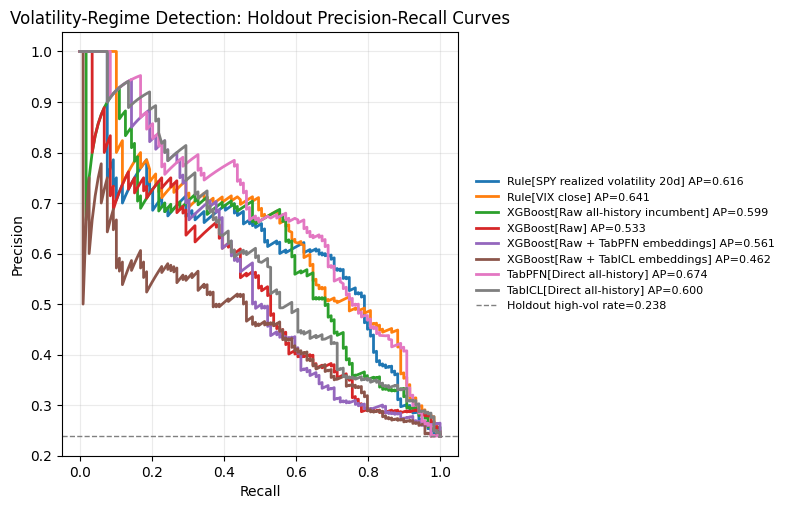

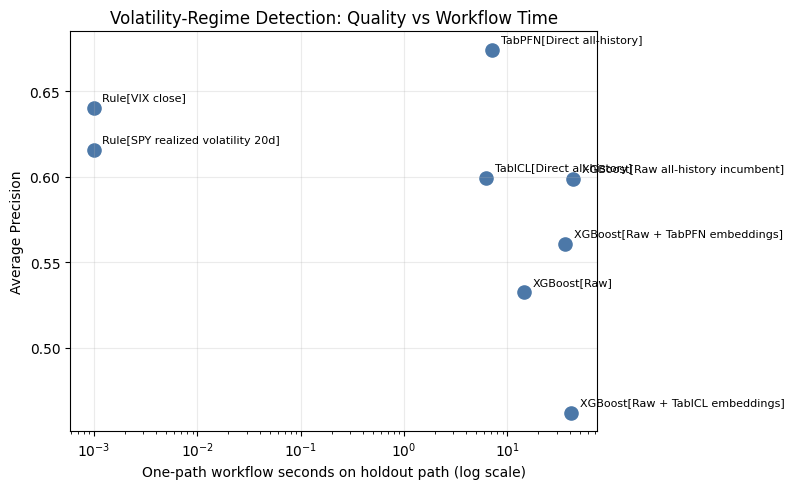

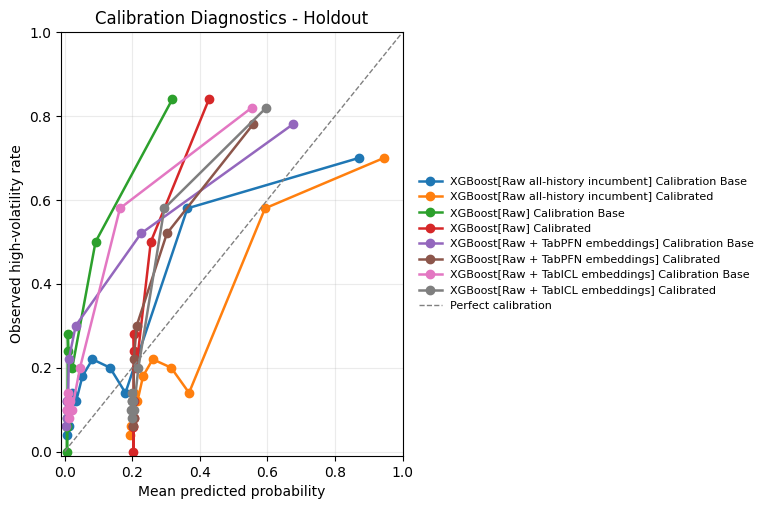

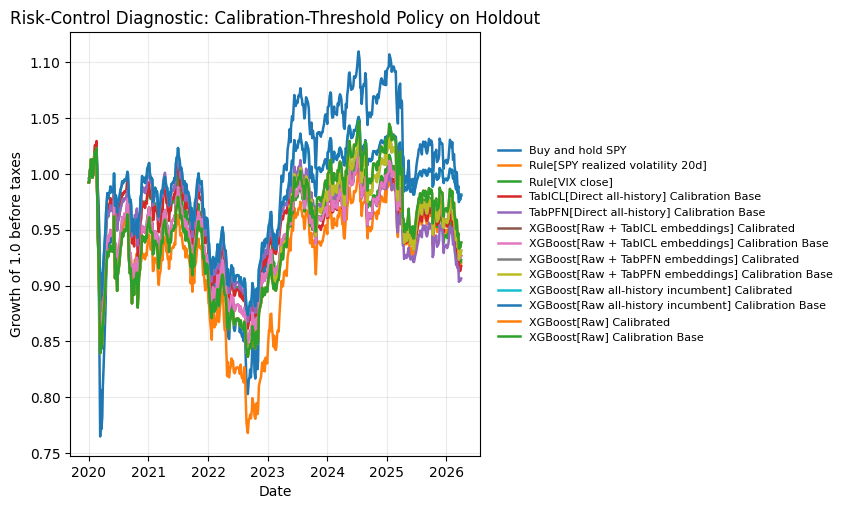

In [8]:
def selected_publication_rows(summary, eval_name="holdout"):
    rows = []
    for model_name in PUBLICATION_MODEL_ORDER:
        candidates = summary.loc[(summary["Evaluation Window"] == eval_name) & (summary["Model"] == model_name) & summary["Average Precision"].notna()]
        if len(candidates) > 0:
            rows.append(candidates.iloc[0].copy())
    return pd.DataFrame(rows).reset_index(drop=True) if rows else pd.DataFrame()


def selected_calibration_rows(summary, eval_name="holdout"):
    rows = []
    for model_name in CALIBRATION_MODEL_ORDER:
        candidates = summary.loc[(summary["Evaluation Window"] == eval_name) & (summary["Model"] == model_name) & summary["Average Precision"].notna()]
        if len(candidates) > 0:
            rows.append(candidates.iloc[0].copy())
    return pd.DataFrame(rows).reset_index(drop=True) if rows else pd.DataFrame()

publication_holdout_summary = selected_publication_rows(volatility_summary, "holdout")
if len(publication_holdout_summary) > 0:
    display(publication_holdout_summary[performance_columns].round(4))
    save_artifact_table(publication_holdout_summary, "publication_holdout_summary.csv")


def plot_precision_recall_curves(output_path):
    plot_rows = selected_publication_rows(volatility_summary, "holdout")
    if len(plot_rows) == 0:
        print("No publication rows available for precision-recall plot.")
        return None
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for _, row in plot_rows.iterrows():
        model_name = row["Model"]
        score = predictions.get((model_name, "holdout"))
        if score is None:
            continue
        precision, recall, _ = precision_recall_curve(y_holdout, score)
        ap = average_precision_score(y_holdout, score)
        ax.plot(recall, precision, linewidth=2, label=f"{model_name} AP={ap:.3f}")
    ax.axhline(y_holdout.mean(), color="gray", linestyle="--", linewidth=1, label=f"Holdout high-vol rate={y_holdout.mean():.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Volatility-Regime Detection: Holdout Precision-Recall Curves")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
    ax.grid(alpha=0.25)
    fig.subplots_adjust(right=0.62)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig

_ = plot_precision_recall_curves(ARTIFACT_DIR / "publication_precision_recall_curves_holdout.png")


def plot_runtime_vs_ap(output_path):
    plot_df = selected_publication_rows(volatility_summary, "holdout")
    plot_df = plot_df.loc[plot_df["Workflow Seconds"].notna() & plot_df["Average Precision"].notna()].copy()
    if len(plot_df) == 0:
        print("No runtime/AP rows available.")
        return None
    plot_df = plot_df.sort_values("Workflow Seconds").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(plot_df["Workflow Seconds"].clip(lower=1e-3), plot_df["Average Precision"], s=90, color="#4C78A8")
    for _, row in plot_df.iterrows():
        ax.annotate(row["Model"], (max(row["Workflow Seconds"], 1e-3), row["Average Precision"]), xytext=(6, 5), textcoords="offset points", fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("One-path workflow seconds on holdout path (log scale)")
    ax.set_ylabel("Average Precision")
    ax.set_title("Volatility-Regime Detection: Quality vs Workflow Time")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig

_ = plot_runtime_vs_ap(ARTIFACT_DIR / "publication_runtime_vs_average_precision_holdout.png")


def plot_calibration_curves(output_path):
    plot_rows = selected_calibration_rows(volatility_summary, "holdout")
    plot_rows = plot_rows.loc[plot_rows["Score Type"] == "probability"].copy()
    if len(plot_rows) == 0:
        print("No selected calibration rows available.")
        return None
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    max_value = 0.0
    for _, row in plot_rows.iterrows():
        model_name = row["Model"]
        score = predictions.get((model_name, "holdout"))
        if score is None:
            continue
        prob_true, prob_pred = calibration_curve(y_holdout, np.clip(score, 1e-7, 1 - 1e-7), n_bins=10, strategy="quantile")
        max_value = max(max_value, float(np.max(prob_true)), float(np.max(prob_pred)))
        ax.plot(prob_pred, prob_true, marker="o", linewidth=1.8, label=model_name)
    max_axis = min(1.0, max(0.20, max_value * 1.15))
    ax.plot([0, max_axis], [0, max_axis], color="gray", linestyle="--", linewidth=1, label="Perfect calibration")
    ax.set_xlim(-0.01, max_axis)
    ax.set_ylim(-0.01, max_axis)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed high-volatility rate")
    ax.set_title("Calibration Diagnostics - Holdout")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
    ax.grid(alpha=0.25)
    fig.subplots_adjust(right=0.58)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig

_ = plot_calibration_curves(ARTIFACT_DIR / "publication_calibration_curves_holdout.png")


def all_reliability_tables():
    rows = []
    for (model_name, eval_name), score in predictions.items():
        summary_row = volatility_summary.loc[(volatility_summary["Model"] == model_name) & (volatility_summary["Evaluation Window"] == eval_name)]
        if len(summary_row) == 0 or summary_row.iloc[0]["Score Type"] != "probability":
            continue
        y_eval = y_calibration if eval_name == "calibration" else y_holdout
        table = calibration_bin_table(y_eval, np.clip(score, 1e-7, 1 - 1e-7), n_bins=10)
        table.insert(0, "Evaluation Window", eval_name)
        table.insert(0, "Model", model_name)
        rows.append(table)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

reliability_summary = all_reliability_tables()
if len(reliability_summary) > 0:
    save_artifact_table(reliability_summary, "reliability_summary.csv")
    selected_names = set(selected_calibration_rows(volatility_summary, "holdout")["Model"])
    publication_reliability_holdout = reliability_summary.loc[(reliability_summary["Evaluation Window"] == "holdout") & (reliability_summary["Model"].isin(selected_names))].copy()
    if len(publication_reliability_holdout) > 0:
        display(publication_reliability_holdout.round(6))
        save_artifact_table(publication_reliability_holdout, "publication_reliability_summary_holdout.csv")


def operating_point_table(y_true, score, model_name, eval_name):
    rows = []
    for rate in [0.05, 0.10, 0.20, 0.30]:
        precision, recall, alerts = top_rate_metrics(y_true, score, rate)
        rows.append({"Model": model_name, "Evaluation Window": eval_name, "Type": "top_rate", "Value": rate, "Alerts": alerts, "Precision": precision, "Recall": recall})
    for target_recall in [0.50, 0.70, 0.80, 0.90]:
        alerts, precision, recall = target_recall_metrics(y_true, score, target_recall)
        rows.append({"Model": model_name, "Evaluation Window": eval_name, "Type": "target_recall", "Value": target_recall, "Alerts": alerts, "Precision": precision, "Recall": recall})
    return pd.DataFrame(rows)

operating_rows = []
for (model_name, eval_name), score in predictions.items():
    if eval_name == "holdout":
        operating_rows.append(operating_point_table(y_holdout, score, model_name, eval_name))
operating_summary = pd.concat(operating_rows, ignore_index=True) if operating_rows else pd.DataFrame()
if len(operating_summary) > 0:
    display(operating_summary.round(4))
    save_artifact_table(operating_summary, "operating_summary.csv")
    publication_operating_summary = operating_summary.loc[operating_summary["Model"].isin(PUBLICATION_MODEL_ORDER)].copy()
    display(publication_operating_summary.round(4))
    save_artifact_table(publication_operating_summary, "publication_operating_summary.csv")


def month_block_bootstrap_uncertainty(n_iterations=BOOTSTRAP_ITERATIONS):
    selected = selected_publication_rows(volatility_summary, "holdout")
    if len(selected) == 0 or n_iterations <= 0:
        return pd.DataFrame()
    rng = np.random.default_rng(SEED)
    months = pd.Series(holdout_df.index.to_period("M"), index=np.arange(len(holdout_df)))
    unique_months = months.unique()
    rows = []
    selected_records = list(selected.iterrows())
    for _, selected_row in tqdm(selected_records, desc="Bootstrap selected models", unit="model"):
        model_name = selected_row["Model"]
        score = predictions.get((model_name, "holdout"))
        if score is None:
            continue
        score = np.asarray(score, dtype=float)
        y_values = y_to_numpy(y_holdout)
        metric_samples = {"average_precision": [], "roc_auc": [], "top_20_recall": []}
        for _ in tqdm(range(n_iterations), desc=f"Bootstrap {model_name}", unit="sample", leave=False):
            sampled_months = rng.choice(unique_months, size=len(unique_months), replace=True)
            sampled_indices = np.concatenate([months.index[months == month].to_numpy() for month in sampled_months])
            y_sample = y_values[sampled_indices]
            if y_sample.sum() == 0 or y_sample.sum() == len(y_sample):
                continue
            score_sample = score[sampled_indices]
            metric_samples["average_precision"].append(average_precision_score(y_sample, score_sample))
            metric_samples["roc_auc"].append(roc_auc_score(y_sample, score_sample))
            metric_samples["top_20_recall"].append(top_rate_metrics(y_sample, score_sample, 0.20)[1])
        point_estimates = {"average_precision": selected_row["Average Precision"], "roc_auc": selected_row["ROC AUC"], "top_20_recall": selected_row["Top 20% Recall"]}
        for metric_name, values in metric_samples.items():
            values = np.asarray(values, dtype=float)
            alpha = 1.0 - BOOTSTRAP_CONFIDENCE_LEVEL
            lower, median, upper = np.quantile(values, [alpha / 2.0, 0.5, 1.0 - alpha / 2.0]) if len(values) else (np.nan, np.nan, np.nan)
            rows.append({"Model": model_name, "Metric": metric_name, "Point Estimate": point_estimates.get(metric_name, np.nan), "Bootstrap Median": median, "CI Lower": lower, "CI Upper": upper, "Bootstrap Iterations Requested": n_iterations, "Bootstrap Iterations Used": len(values), "Block Unit": "calendar_month", "Confidence Level": BOOTSTRAP_CONFIDENCE_LEVEL})
    return pd.DataFrame(rows)

publication_bootstrap_uncertainty = month_block_bootstrap_uncertainty()
if len(publication_bootstrap_uncertainty) > 0:
    display(publication_bootstrap_uncertainty.round(4))
    save_artifact_table(publication_bootstrap_uncertainty, "publication_month_block_bootstrap_uncertainty.csv")



def portfolio_metrics(daily_returns, weights=None, transaction_cost_bps=TRANSACTION_COST_BPS):
    returns = pd.Series(daily_returns).astype(float).fillna(0.0).reset_index(drop=True)
    weights = pd.Series(np.ones(len(returns)) if weights is None else weights).astype(float).reset_index(drop=True)
    turnover = weights.diff().abs().fillna(abs(weights.iloc[0] - 1.0))
    cost = turnover * transaction_cost_bps / 10000.0
    strategy_returns = weights * returns - cost
    equity = (1.0 + strategy_returns).cumprod()
    years = len(strategy_returns) / TRADING_DAYS_PER_YEAR
    cagr = equity.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 and equity.iloc[-1] > 0 else np.nan
    ann_vol = strategy_returns.std(ddof=1) * math.sqrt(TRADING_DAYS_PER_YEAR)
    sharpe = strategy_returns.mean() / strategy_returns.std(ddof=1) * math.sqrt(TRADING_DAYS_PER_YEAR) if strategy_returns.std(ddof=1) > 0 else np.nan
    downside = strategy_returns[strategy_returns < 0]
    sortino = strategy_returns.mean() / downside.std(ddof=1) * math.sqrt(TRADING_DAYS_PER_YEAR) if len(downside) > 1 and downside.std(ddof=1) > 0 else np.nan
    drawdown = equity / equity.cummax() - 1.0
    return {"CAGR": cagr, "Annualized Volatility": ann_vol, "Sharpe": sharpe, "Sortino": sortino, "Max Drawdown": drawdown.min(), "Average Weight": weights.mean(), "Annualized Turnover": turnover.sum() / years if years > 0 else np.nan, "Total Transaction Cost": cost.sum(), "Final Equity": equity.iloc[-1]}, equity, strategy_returns

holdout_next_returns = holdout_df["spy_next_1d_return"].astype(float).copy()
policy_candidate_names = sorted(set(volatility_summary.loc[volatility_summary["Evaluation Window"] == "calibration", "Model"]) & set(volatility_summary.loc[volatility_summary["Evaluation Window"] == "holdout", "Model"]))
policy_rows = []
selected_policy_rows = []
equity_curves = pd.DataFrame(index=holdout_df.index)
strategy_return_curves = pd.DataFrame(index=holdout_df.index)

buy_hold_metrics, buy_hold_equity, buy_hold_returns = portfolio_metrics(holdout_next_returns, weights=np.ones(len(holdout_next_returns)))
buy_hold_metrics.update({"Model": "Buy and hold SPY", "Threshold Source": "none", "Risk Action Rate in Holdout": 0.0, "Calibration Score Threshold": np.nan, "Target Action Rate": 0.0, "High-Risk Weight": 1.0})
policy_rows.append(buy_hold_metrics.copy())
selected_policy_rows.append(buy_hold_metrics.copy())
equity_curves["Buy and hold SPY"] = buy_hold_equity.values
strategy_return_curves["Buy and hold SPY"] = buy_hold_returns.values

for model_name in tqdm(policy_candidate_names, desc="Risk-policy model diagnostics", unit="model"):
    calibration_score = predictions.get((model_name, "calibration"))
    holdout_score = predictions.get((model_name, "holdout"))
    if calibration_score is None or holdout_score is None:
        continue
    for target_action_rate in RISK_POLICY_GRID_ACTION_RATES:
        threshold = float(np.quantile(calibration_score, 1.0 - target_action_rate))
        high_risk_flag = np.asarray(holdout_score, dtype=float) >= threshold
        for high_risk_weight in RISK_POLICY_GRID_HIGH_RISK_WEIGHTS:
            weights = np.where(high_risk_flag, high_risk_weight, 1.0)
            metrics, equity, strategy_returns = portfolio_metrics(holdout_next_returns, weights=weights)
            metrics.update(
                {
                    "Model": model_name,
                    "Threshold Source": "calibration_window_score_quantile",
                    "Risk Action Rate in Holdout": float(high_risk_flag.mean()),
                    "Calibration Score Threshold": threshold,
                    "Target Action Rate": target_action_rate,
                    "High-Risk Weight": high_risk_weight,
                }
            )
            policy_rows.append(metrics)
            if np.isclose(target_action_rate, RISK_POLICY_PLOT_ACTION_RATE) and np.isclose(high_risk_weight, RISK_POLICY_PLOT_HIGH_RISK_WEIGHT):
                selected_policy_rows.append(metrics.copy())
                equity_curves[model_name] = equity.values
                strategy_return_curves[model_name] = strategy_returns.values

risk_policy_grid_summary = pd.DataFrame(policy_rows).sort_values(["Max Drawdown", "Sharpe"], ascending=[False, False]).reset_index(drop=True)
risk_policy_selected_summary = pd.DataFrame(selected_policy_rows).sort_values(["Max Drawdown", "Sharpe"], ascending=[False, False]).reset_index(drop=True)

display(risk_policy_grid_summary.round(4))
display(risk_policy_selected_summary.round(4))
save_artifact_table(risk_policy_grid_summary, "risk_policy_grid_summary.csv", description="Full grid of calibration-threshold exposure-reduction diagnostics.")
save_artifact_table(risk_policy_selected_summary, "risk_policy_selected_summary.csv", description="Selected risk-policy configuration used for plotted equity curves.")
save_artifact_table(equity_curves.reset_index(names="date"), "risk_policy_equity_curves.csv", description="Holdout equity curves for selected risk-policy diagnostics.")
save_artifact_table(strategy_return_curves.reset_index(names="date"), "risk_policy_daily_returns.csv", description="Holdout daily returns for selected risk-policy diagnostics.")

if len(equity_curves.columns) > 0:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for column in tqdm(equity_curves.columns, desc="Plotting risk-policy equity curves", unit="curve", leave=False):
        ax.plot(equity_curves.index, equity_curves[column], linewidth=1.8, label=column)
    ax.set_title("Risk-Control Diagnostic: Calibration-Threshold Policy on Holdout")
    ax.set_xlabel("Date")
    ax.set_ylabel("Growth of 1.0 before taxes")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
    ax.grid(alpha=0.25)
    fig.subplots_adjust(right=0.58)
    output_path = ARTIFACT_DIR / "risk_policy_equity_curves.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved {output_path}")

if len(publication_holdout_summary) > 0:
    save_text_artifact("publication_holdout_summary.txt", publication_holdout_summary[performance_columns].round(6).to_string(index=False), description="Plain-text publication holdout table for review outside the notebook editor.")
if len(operating_summary) > 0:
    save_text_artifact("publication_operating_summary.txt", publication_operating_summary.round(6).to_string(index=False), description="Plain-text operating-point table for review outside the notebook editor.")
if len(publication_bootstrap_uncertainty) > 0:
    save_text_artifact("publication_bootstrap_uncertainty.txt", publication_bootstrap_uncertainty.round(6).to_string(index=False), description="Plain-text block-bootstrap uncertainty table.")
if len(risk_policy_selected_summary) > 0:
    save_text_artifact("risk_policy_selected_summary.txt", risk_policy_selected_summary.round(6).to_string(index=False), description="Plain-text selected risk-policy diagnostic table.")


## 7. Drift, Leakage, and Reuse Checklist

Market data creates several leakage risks that need explicit review. The target intentionally uses future returns, so the central question is whether any future target information is allowed into the features, threshold selection, model selection, calibration, or holdout decision rule. This checklist records what the public-data workflow can verify and what remains a limitation.


In [9]:
def yearly_metric_summary():
    selected = selected_publication_rows(volatility_summary, "holdout")
    rows = []
    years = holdout_df.index.year
    for _, selected_row in tqdm(list(selected.iterrows()), desc="Yearly holdout metrics", unit="model"):
        model_name = selected_row["Model"]
        score = predictions.get((model_name, "holdout"))
        if score is None:
            continue
        score = np.asarray(score, dtype=float)
        y_values = y_to_numpy(y_holdout)
        for year in sorted(np.unique(years)):
            mask = years == year
            if mask.sum() < 20:
                continue
            y_year = y_values[mask]
            score_year = score[mask]
            rows.append({"Model": model_name, "Year": int(year), "Rows": int(mask.sum()), "High Vol Rows": int(y_year.sum()), "High Vol Rate": float(y_year.mean()), "Average Precision": safe_metric(average_precision_score, y_year, score_year), "ROC AUC": safe_metric(roc_auc_score, y_year, score_year), "Top 20% Recall": top_rate_metrics(y_year, score_year, 0.20)[1]})
    return pd.DataFrame(rows)

yearly_holdout_summary = yearly_metric_summary()
if len(yearly_holdout_summary) > 0:
    display(yearly_holdout_summary.round(4))
    save_artifact_table(yearly_holdout_summary, "yearly_holdout_summary.csv")


def population_stability_index(expected, actual, n_bins=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if len(expected) < n_bins or len(actual) < n_bins:
        return np.nan
    quantiles = np.unique(np.quantile(expected, np.linspace(0.0, 1.0, n_bins + 1)))
    if len(quantiles) <= 2:
        return np.nan
    expected_bins = pd.cut(expected, bins=quantiles, include_lowest=True, duplicates="drop")
    actual_bins = pd.cut(actual, bins=quantiles, include_lowest=True, duplicates="drop")
    expected_pct = expected_bins.value_counts(normalize=True, sort=False).replace(0.0, 1e-6)
    actual_pct = actual_bins.value_counts(normalize=True, sort=False).reindex(expected_pct.index).fillna(1e-6).replace(0.0, 1e-6)
    return float(((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum())

preholdout_df = pd.concat([context_df, tune_df, calibration_df], axis=0)
feature_drift_rows = []
for column in tqdm(feature_columns, desc="Computing feature drift PSI", unit="feature"):
    feature_drift_rows.append({"Feature": column, "Preholdout Mean": preholdout_df[column].mean(), "Holdout Mean": holdout_df[column].mean(), "Preholdout Std": preholdout_df[column].std(), "Holdout Std": holdout_df[column].std(), "PSI": population_stability_index(preholdout_df[column], holdout_df[column], n_bins=10)})
feature_drift_summary = pd.DataFrame(feature_drift_rows).sort_values("PSI", ascending=False, na_position="last").reset_index(drop=True)
display(feature_drift_summary.head(30).round(4))
save_artifact_table(feature_drift_summary, "feature_drift_summary.csv")

chronological_split_ordered = context_df.index.max() < tune_df.index.min() and tune_df.index.max() < calibration_df.index.min() and calibration_df.index.max() < holdout_df.index.min()
feature_name_leakage_flags = [column for column in feature_columns if column.startswith("target_") or "forward" in column.lower() or "next_" in column.lower()]
leakage_checks = pd.DataFrame(
    [
        {"Check": "Target columns excluded from features", "Status": "pass" if not feature_name_leakage_flags else "fail", "Evidence": f"flagged_feature_columns={feature_name_leakage_flags[:10]}; feature_count={len(feature_columns)}"},
        {"Check": "High-volatility threshold estimated before calibration and holdout", "Status": "pass", "Evidence": f"threshold_source_end_date={TUNING_END_DATE}; threshold={HIGH_VOL_THRESHOLD:.6f}; quantile={HIGH_VOL_QUANTILE:.2f}"},
        {"Check": "Chronological split order", "Status": "pass" if chronological_split_ordered else "fail", "Evidence": f"context_max={context_df.index.max().date()}, tune_min={tune_df.index.min().date()}, tune_max={tune_df.index.max().date()}, calibration_min={calibration_df.index.min().date()}, holdout_min={holdout_df.index.min().date()}"},
        {"Check": "TFM embedding context reused as downstream labels", "Status": "not_used_in_fair_embedding_path", "Evidence": "embedding context labels condition TabPFN/TabICL embeddings; fair embedding-enhanced XGBoost excludes context rows from downstream fitting"},
        {"Check": "Raw all-history incumbent separated from fair embedding comparison", "Status": "pass", "Evidence": "raw all-history incumbent is reported as a separate classical reference point"},
        {"Check": "Calibration window used for final uncalibrated refit", "Status": "review", "Evidence": "final uncalibrated rows use all pre-holdout labels; calibration-base and calibrated rows are reported separately for threshold/probability diagnostics"},
        {"Check": "Overlapping target windows", "Status": "known_limitation", "Evidence": f"future realized-volatility labels use overlapping {TARGET_HORIZON_DAYS}-day windows; uncertainty is reported with calendar-month block bootstrap rather than iid row bootstrap"},
        {"Check": "Investment decision interpretation", "Status": "educational_only", "Evidence": "risk-policy section is a diagnostic of score utility, not an investment recommendation"},
    ]
)
display(leakage_checks)
save_artifact_table(leakage_checks, "leakage_checks.csv")

if cuda_memory_snapshots:
    cuda_memory_summary = pd.concat(cuda_memory_snapshots, ignore_index=True)
    save_artifact_table(cuda_memory_summary, "cuda_memory_summary_final.csv", description="Final CUDA memory summary collected during the run.")


Yearly holdout metrics:   0%|          | 0/8 [00:00<?, ?model/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379:

,Model,Year,Rows,High Vol Rows,High Vol Rate,Average Precision,ROC AUC,Top 20% Recall
0,Rule[SPY realized volatility 20d],2020,81,43,0.5309,0.7382,0.6573,0.3256
1,Rule[SPY realized volatility 20d],2021,80,1,0.0125,0.0128,0.0253,0.0000
2,Rule[SPY realized volatility 20d],2022,80,58,0.7250,0.7689,0.5165,0.2069
3,Rule[SPY realized volatility 20d],2023,79,0,0.0000,0.0000,NaN,0.0000
4,Rule[SPY realized volatility 20d],2024,80,4,0.0500,0.0457,0.3257,0.0000
5,Rule[SPY realized volatility 20d],2025,80,12,0.1500,0.3821,0.7880,0.7500
6,Rule[SPY realized volatility 20d],2026,20,1,0.0500,0.0769,0.3684,0.0000
7,Rule[VIX close],2020,81,43,0.5309,0.7465,0.6769,0.3023
8,Rule[VIX close],2021,80,1,0.0125,0.0303,0.5949,0.0000
9,Rule[VIX close],2022,80,58,0.7250,0.8333,0.6375,0.2414


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/yearly_holdout_summary.csv


Computing feature drift PSI:   0%|          | 0/574 [00:00<?, ?feature/s]

,Feature,Preholdout Mean,Holdout Mean,Preholdout Std,Holdout Std,PSI
0,yield_curve_10y_2y,1.2869,0.2404,0.8676,0.6227,4.3909
1,computed_yield_curve_10y_2y,1.2869,0.2404,0.8676,0.6227,4.3776
2,fed_funds_rate,1.2397,2.7824,1.6061,2.1843,4.0455
3,corr_spy_tlt_126d,-0.3929,-0.0425,0.2017,0.2380,3.0776
4,iwm_rv_126d,0.2066,0.2497,0.0986,0.0855,2.5730
5,corr_spy_eem_126d,0.8019,0.6959,0.0955,0.1060,2.5638
6,corr_qqq_tlt_126d,-0.3364,-0.0034,0.2002,0.2224,2.3083
7,treasury_10y_yield,2.7898,3.0044,0.9361,1.4020,2.0066
8,vnq_rv_126d,0.2262,0.2168,0.1901,0.1079,1.9941
9,vnq_volume_volatility_20d,0.4133,0.3021,0.1565,0.0807,1.8937


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/feature_drift_summary.csv


,Check,Status,Evidence
0,Target columns excluded from features,pass,flagged_feature_columns=[]; feature_count=574
1,High-volatility threshold estimated before cal...,pass,threshold_source_end_date=2017-12-29; threshol...
2,Chronological split order,pass,"context_max=2011-12-30, tune_min=2012-01-03, t..."
3,TFM embedding context reused as downstream labels,not_used_in_fair_embedding_path,embedding context labels condition TabPFN/TabI...
4,Raw all-history incumbent separated from fair ...,pass,raw all-history incumbent is reported as a sep...
5,Calibration window used for final uncalibrated...,review,final uncalibrated rows use all pre-holdout la...
6,Overlapping target windows,known_limitation,future realized-volatility labels use overlapp...
7,Investment decision interpretation,educational_only,risk-policy section is a diagnostic of score u...


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/leakage_checks.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/cuda_memory_summary_final.csv


## 8. Save Output Archive

This final section creates a manifest and ZIP archive of the run artifacts. The archive is intended for downloading from Kaggle and reviewing outside the notebook editor.


In [10]:
registered_artifact_manifest = pd.DataFrame(artifact_manifest_rows).drop_duplicates(subset=["path", "kind"], keep="last")
if len(registered_artifact_manifest) > 0:
    display(registered_artifact_manifest)
    save_artifact_table(registered_artifact_manifest, "registered_artifact_manifest.csv", description="Artifacts explicitly registered by notebook helper functions.")

run_closeout = f"""
# Run Closeout

Artifact directory: {ARTIFACT_DIR}
Run mode: {"FAST_MODE smoke test" if FAST_MODE else "full research run"}
Rows in model frame: {len(model_frame):,}
Feature count: {len(feature_columns):,}
Holdout rows: {len(holdout_df):,}
Holdout high-volatility rate: {y_holdout.mean():.4%}
Successful model rows: {len(volatility_summary):,}
Model errors: {len(model_errors):,}

Use the CSV/TXT/PNG artifacts for offline review because notebook editor output can be truncated.
""".strip()
save_text_artifact("run_closeout.md", run_closeout, description="Final run-level summary and artifact guidance.")

artifact_file_rows = []
for artifact_path in tqdm(sorted(ARTIFACT_DIR.glob("**/*")), desc="Building artifact manifest", unit="path"):
    if artifact_path.is_file():
        artifact_file_rows.append(
            {
                "path": str(artifact_path),
                "filename": artifact_path.name,
                "suffix": artifact_path.suffix,
                "size_bytes": artifact_path.stat().st_size,
            }
        )

artifact_file_manifest = pd.DataFrame(artifact_file_rows)
if len(artifact_file_manifest) > 0:
    display(artifact_file_manifest)
    save_artifact_table(artifact_file_manifest, "artifact_file_manifest.csv", description="Files present in the artifact directory at archive time.")

import shutil

archive_base_candidates = [
    Path("/kaggle/working/tabpfn_tabicl_volatility_regime_20260506_outputs"),
    ARTIFACT_DIR.parent / "tabpfn_tabicl_volatility_regime_20260506_outputs",
]
for archive_base in archive_base_candidates:
    try:
        archive_base.parent.mkdir(parents=True, exist_ok=True)
        archive_path = shutil.make_archive(str(archive_base), "zip", ARTIFACT_DIR)
        print(f"Created {archive_path}")
        break
    except Exception as exc:
        print(f"Could not create archive at {archive_base}.zip: {short_error(exc)}")

print("Notebook workflow complete. Review CSV, TXT, and PNG artifacts for the run record.")


,path,filename,kind,description,exists,size_bytes
0,tabpfn_tabicl_volatility_regime_20260506_outpu...,environment_summary.csv,table,,True,179
1,tabpfn_tabicl_volatility_regime_20260506_outpu...,source_provenance_summary.csv,table,,True,257
2,tabpfn_tabicl_volatility_regime_20260506_outpu...,cuda_memory_after_imports.csv,table,,True,244
3,tabpfn_tabicl_volatility_regime_20260506_outpu...,configuration_summary.csv,table,Notebook configuration values used for this run.,True,972
4,tabpfn_tabicl_volatility_regime_20260506_outpu...,method_contract.md,text,Plain-language modeling and evaluation contract.,True,1228
5,tabpfn_tabicl_volatility_regime_20260506_outpu...,data_source_summary.csv,table,,True,522
6,tabpfn_tabicl_volatility_regime_20260506_outpu...,target_definition_summary.csv,table,,True,484
7,tabpfn_tabicl_volatility_regime_20260506_outpu...,feature_policy_summary.csv,table,,True,310
8,tabpfn_tabicl_volatility_regime_20260506_outpu...,feature_quality_summary.csv,table,,True,21218
9,tabpfn_tabicl_volatility_regime_20260506_outpu...,sparse_feature_summary.csv,table,,True,729


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/registered_artifact_manifest.csv
Saved tabpfn_tabicl_volatility_regime_20260506_outputs/run_closeout.md


Building artifact manifest:   0%|          | 0/48 [00:00<?, ?path/s]

,path,filename,suffix,size_bytes
0,tabpfn_tabicl_volatility_regime_20260506_outpu...,best_params.csv,.csv,7005
1,tabpfn_tabicl_volatility_regime_20260506_outpu...,calibration_quality_view.csv,.csv,4471
2,tabpfn_tabicl_volatility_regime_20260506_outpu...,configuration_summary.csv,.csv,972
3,tabpfn_tabicl_volatility_regime_20260506_outpu...,cuda_memory_after_imports.csv,.csv,244
4,tabpfn_tabicl_volatility_regime_20260506_outpu...,cuda_memory_summary.csv,.csv,956
5,tabpfn_tabicl_volatility_regime_20260506_outpu...,cuda_memory_summary_final.csv,.csv,956
6,tabpfn_tabicl_volatility_regime_20260506_outpu...,cv_summary.csv,.csv,376
7,tabpfn_tabicl_volatility_regime_20260506_outpu...,data_source_summary.csv,.csv,522
8,tabpfn_tabicl_volatility_regime_20260506_outpu...,embedding_matrix_summary.csv,.csv,438
9,tabpfn_tabicl_volatility_regime_20260506_outpu...,embedding_source_summary.csv,.csv,460


Saved tabpfn_tabicl_volatility_regime_20260506_outputs/artifact_file_manifest.csv
Created /kaggle/working/tabpfn_tabicl_volatility_regime_20260506_outputs.zip
Notebook workflow complete. Review CSV, TXT, and PNG artifacts for the run record.
